# Fashion MNIST — Data Loading, Exploration, Stratified Sampling, MLP & CNN
**Classification Project**

## 0. Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import pandas as pd
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
plt.rcParams['figure.dpi'] = 120

CLASS_NAMES = [
    'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
    'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'
]

print('Imports OK')


Imports OK


---
## 1. Load the Data

In [2]:
import numpy as np
import pandas as pd

df = pd.read_csv('fashion-mnist.csv')
y = df['label'].values.astype(int)
X = df.drop(columns='label').values.astype(np.float32)

print(f'X shape  : {X.shape}')
print(f'y shape  : {y.shape}')
print(f'X dtype  : {X.dtype}')
print(f'Pixel range: [{X.min():.0f}, {X.max():.0f}]')


X shape  : (60000, 784)
y shape  : (60000,)
X dtype  : float32
Pixel range: [0, 255]


---
## 2. Data Exploration

### 2.1 Basic Statistics

In [3]:
stats = {
    'Total samples'     : len(y),
    'Features (pixels)' : X.shape[1],
    'Image size'        : '28 x 28',
    'Number of classes' : len(CLASS_NAMES),
    'Mean pixel value'  : round(float(X.mean()), 3),
    'Std pixel value'   : round(float(X.std()), 3),
    'Min pixel value'   : float(X.min()),
    'Max pixel value'   : float(X.max()),
    'Missing values'    : int(np.isnan(X).sum()),
}
pd.DataFrame.from_dict(stats, orient='index', columns=['Value'])


,Value
Total samples,60000
Features (pixels),784
Image size,28 x 28
Number of classes,10
Mean pixel value,72.957
Std pixel value,89.967
Min pixel value,0.0
Max pixel value,255.0
Missing values,0


### 2.2 Duplicate Check

In [4]:
X_int = X.astype(np.int32)
unique_rows, counts_u = np.unique(X_int, axis=0, return_index=True)

n_dup_groups = len(X) - len(unique_rows)
print(f'Total rows          : {len(X):,}')
print(f'Unique rows         : {len(unique_rows):,}')
print(f'Extra duplicate rows: {n_dup_groups}')

if n_dup_groups == 0:
    print('\n✅ No duplicates found — dataset is clean.')
else:
    print(f'\n⚠️  Found {n_dup_groups} duplicate rows — dropping them.')
    X = X[np.sort(counts_u)]
    y = y[np.sort(counts_u)]
    print(f'After drop: {X.shape[0]:,} rows')


Total rows          : 60,000
Unique rows         : 59,957
Extra duplicate rows: 43

⚠️  Found 43 duplicate rows — dropping them.
After drop: 59,957 rows


### 2.3 Label Check

In [5]:
unique_cls, counts_cls = np.unique(y, return_counts=True)

print(f'Unique labels      : {unique_cls.tolist()}')
print(f'Unexpected labels  : {set(unique_cls) - set(range(10))}')
print(f'Missing labels     : {set(range(10)) - set(unique_cls)}')
print(f'NaN in y           : {np.isnan(y.astype(float)).sum()}')
print()
print(f"{'Label':<8} {'Class Name':<18} {'Count':>8} {'% of total':>12}")
print('-' * 50)
for cls, cnt in zip(unique_cls, counts_cls):
    print(f'  {cls:<6} {CLASS_NAMES[cls]:<18} {cnt:>8,} {cnt/len(y)*100:>11.2f}%')


Unique labels      : [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
Unexpected labels  : set()
Missing labels     : set()
NaN in y           : 0

Label    Class Name            Count   % of total
--------------------------------------------------
  0      T-shirt/top           5,998       10.00%
  1      Trouser               5,996       10.00%
  2      Pullover              5,988        9.99%
  3      Dress                 5,997       10.00%
  4      Coat                  5,995       10.00%
  5      Sandal                6,000       10.01%
  6      Shirt                 5,989        9.99%
  7      Sneaker               5,996       10.00%
  8      Bag                   6,000       10.01%
  9      Ankle boot            5,998       10.00%


### 2.4 Class Distribution & Pixel Histogram

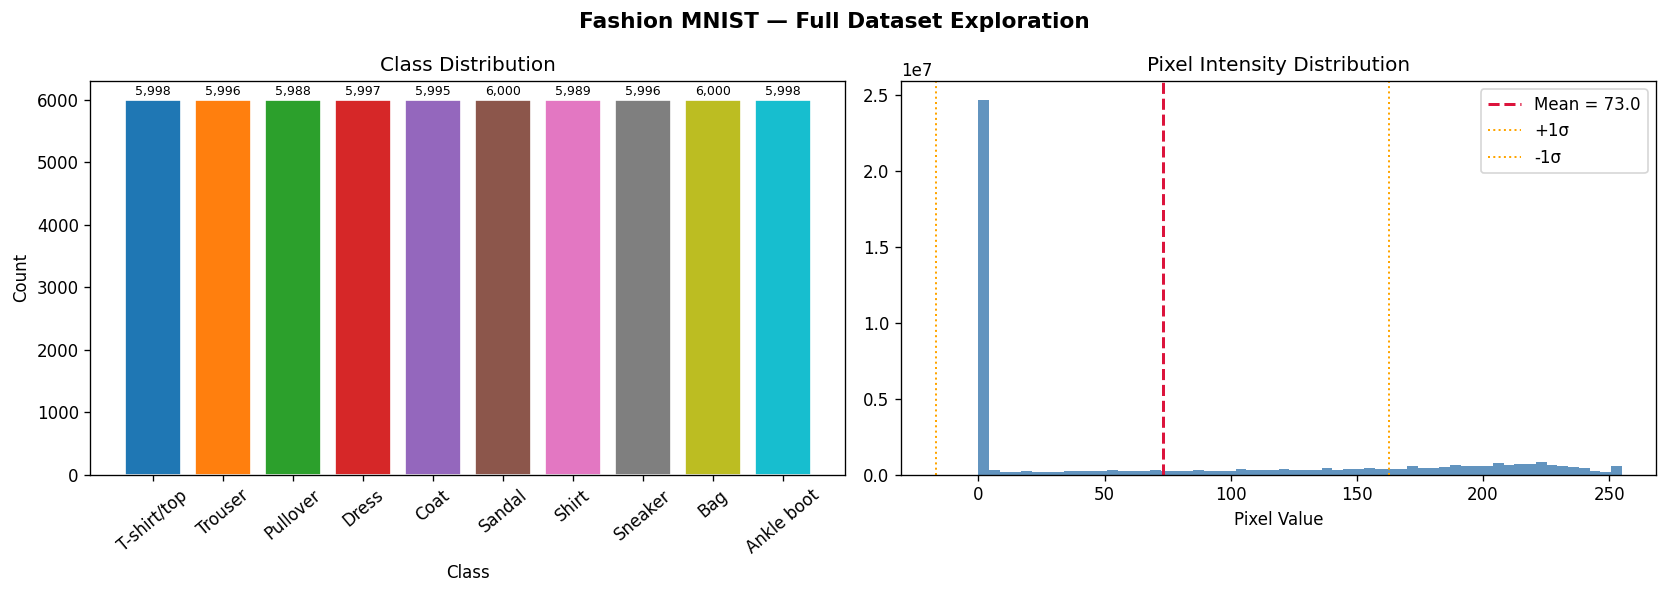

In [6]:
colors = plt.cm.tab10(np.linspace(0, 1, 10))
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Fashion MNIST — Full Dataset Exploration', fontsize=13, fontweight='bold')

axes[0].bar([CLASS_NAMES[i] for i in unique_cls], counts_cls, color=colors, edgecolor='white')
axes[0].set_title('Class Distribution'); axes[0].set_xlabel('Class'); axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=40)
for i, cnt in enumerate(counts_cls):
    axes[0].text(i, cnt + 80, f'{cnt:,}', ha='center', fontsize=7.5)

axes[1].hist(X.flatten(), bins=60, color='steelblue', alpha=0.85, edgecolor='none')
axes[1].axvline(X.mean(), color='crimson', lw=1.8, linestyle='--', label=f'Mean = {X.mean():.1f}')
axes[1].axvline(X.mean()+X.std(), color='orange', lw=1.2, linestyle=':', label=f'+1σ')
axes[1].axvline(X.mean()-X.std(), color='orange', lw=1.2, linestyle=':', label=f'-1σ')
axes[1].set_title('Pixel Intensity Distribution'); axes[1].set_xlabel('Pixel Value')
axes[1].legend()
plt.tight_layout(); plt.show()


### 2.5 Sample Images per Class

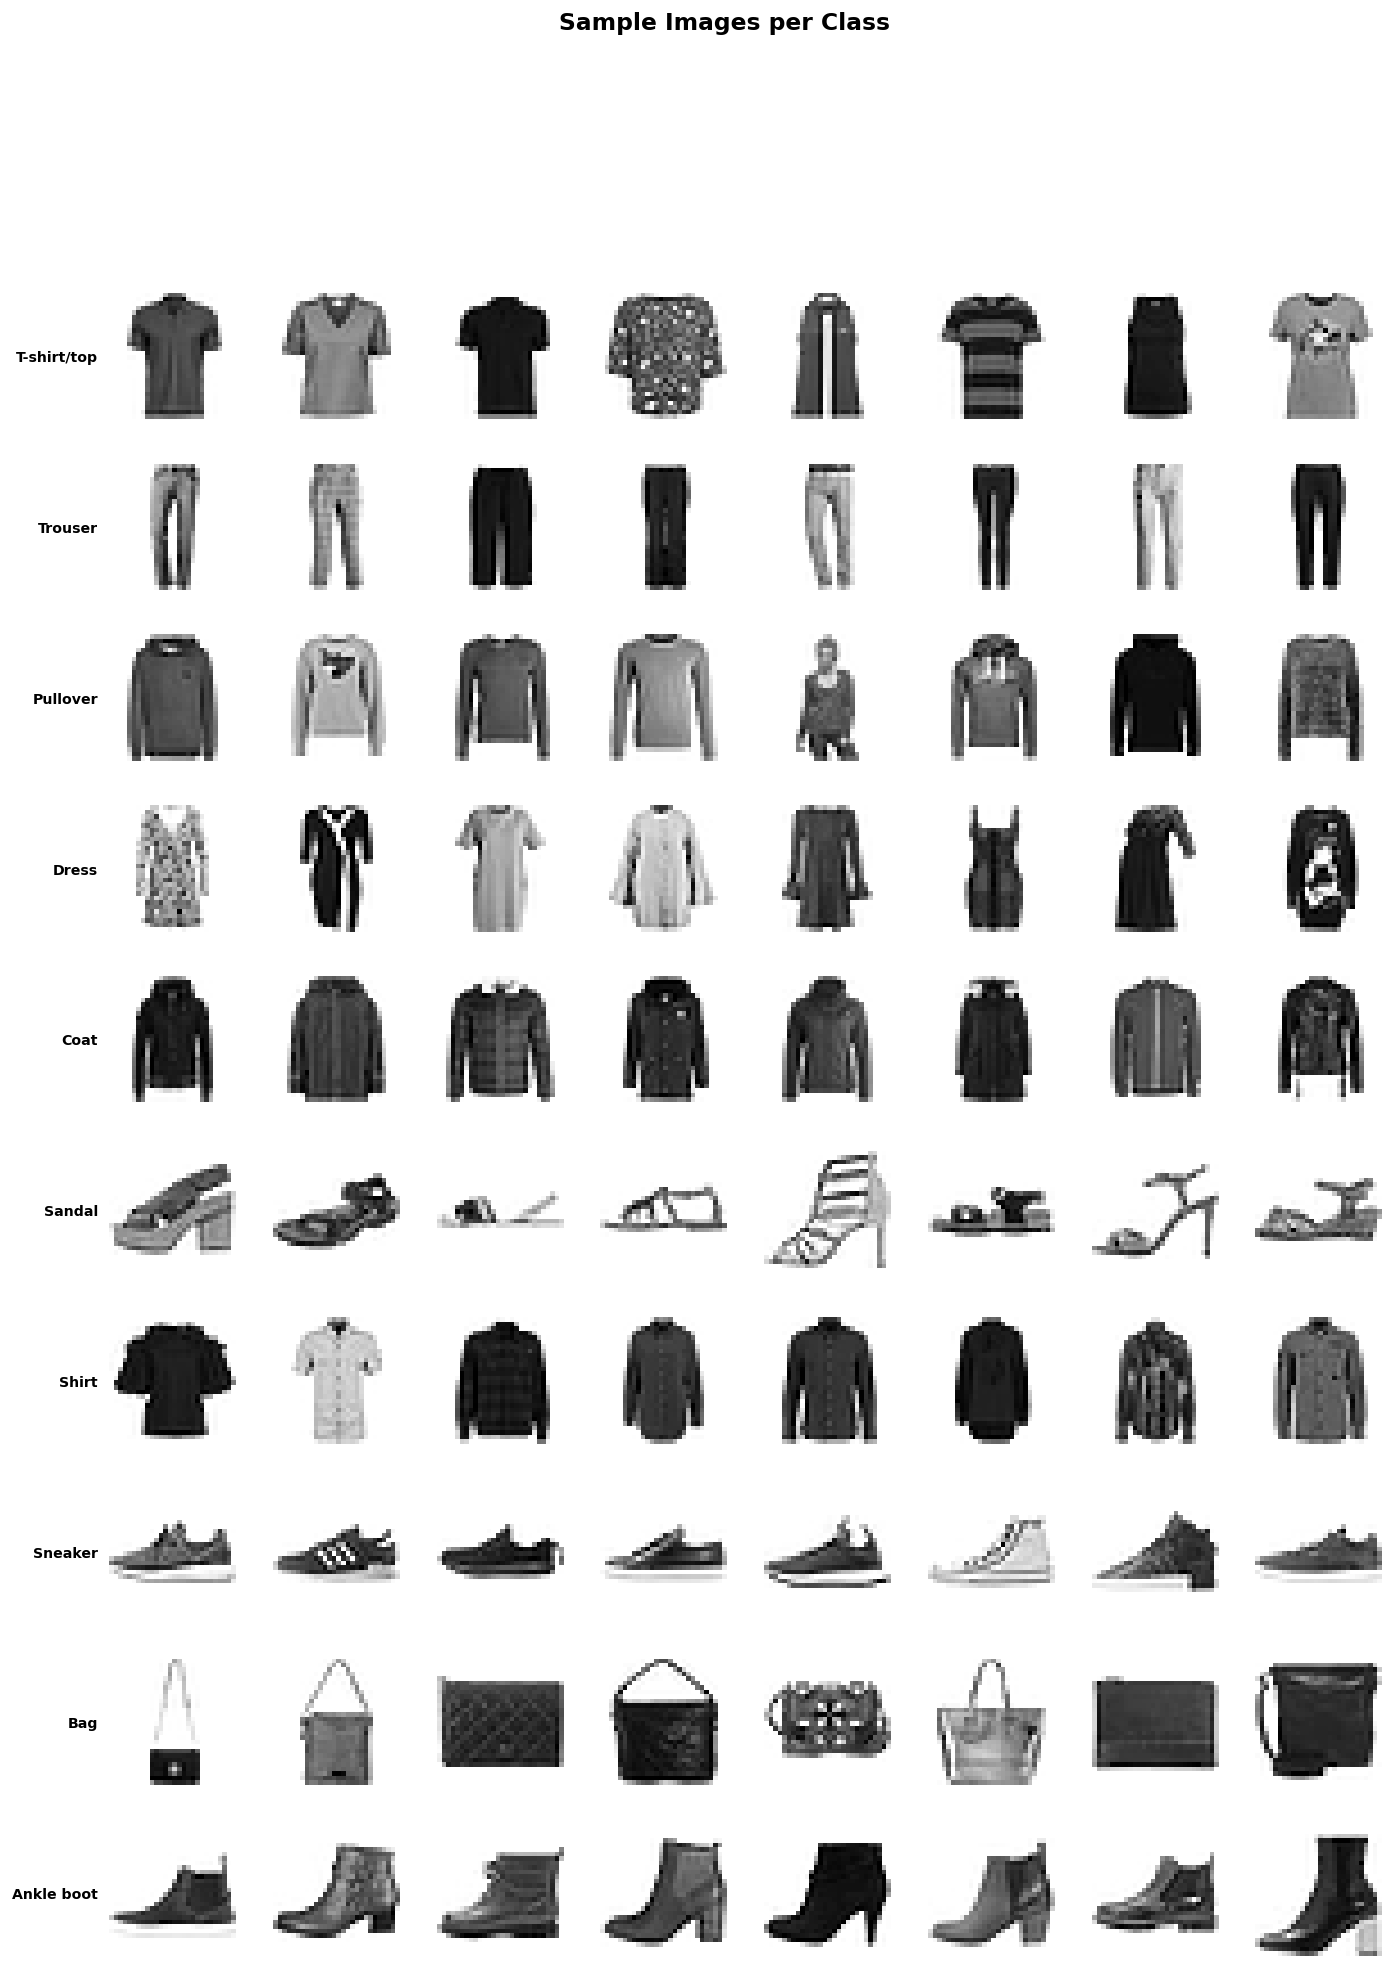

In [7]:
np.random.seed(0)
fig = plt.figure(figsize=(14, 18))
fig.suptitle('Sample Images per Class', fontsize=14, fontweight='bold', y=1.01)
gs = fig.add_gridspec(10, 8, hspace=0.35, wspace=0.05)

for cls in range(10):
    idx = np.where(y == cls)[0]
    samples = np.random.choice(idx, 8, replace=False)
    for col, s in enumerate(samples):
        ax = fig.add_subplot(gs[cls, col])
        ax.imshow(X[s].reshape(28, 28), cmap='gray_r', vmin=0, vmax=255)
        ax.axis('off')
        if col == 0:
            ax.text(-3, 14, CLASS_NAMES[cls], fontsize=8.5, ha='right',
                    va='center', fontweight='bold', transform=ax.transData)
plt.show()


### 2.6 Mean Image & Variance Maps per Class

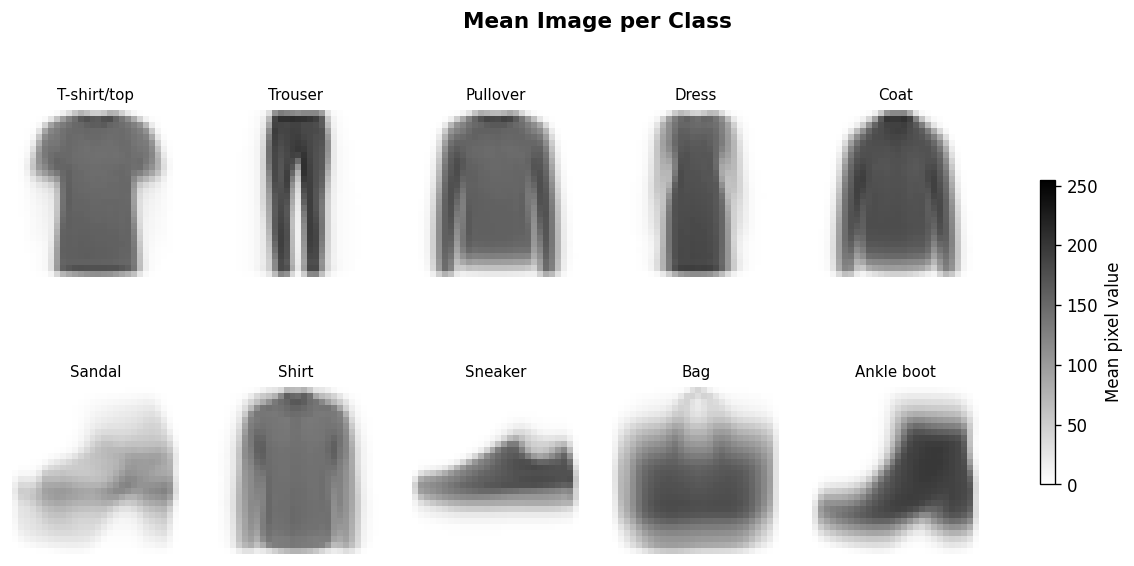

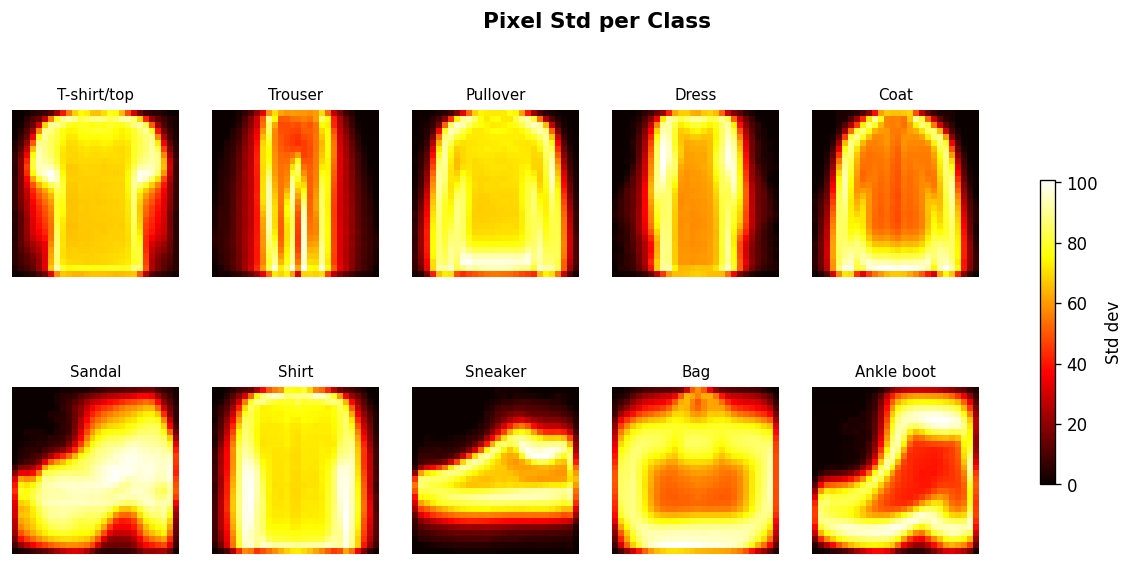

In [8]:
fig, axes = plt.subplots(2, 5, figsize=(13, 5.5))
fig.suptitle('Mean Image per Class', fontsize=13, fontweight='bold')
for cls, ax in zip(range(10), axes.flatten()):
    mean_img = X[y == cls].mean(axis=0).reshape(28, 28)
    im = ax.imshow(mean_img, cmap='gray_r', vmin=0, vmax=255)
    ax.set_title(CLASS_NAMES[cls], fontsize=9); ax.axis('off')
plt.colorbar(im, ax=axes.ravel().tolist(), shrink=0.6, label='Mean pixel value')
plt.show()

fig, axes = plt.subplots(2, 5, figsize=(13, 5.5))
fig.suptitle('Pixel Std per Class', fontsize=13, fontweight='bold')
for cls, ax in zip(range(10), axes.flatten()):
    std_img = X[y == cls].std(axis=0).reshape(28, 28)
    im = ax.imshow(std_img, cmap='hot')
    ax.set_title(CLASS_NAMES[cls], fontsize=9); ax.axis('off')
plt.colorbar(im, ax=axes.ravel().tolist(), shrink=0.6, label='Std dev')
plt.show()


---
## 3. Stratified 10% Sample

In [9]:
X_sample, _, y_sample, _ = train_test_split(
    X, y, train_size=0.10, stratify=y, random_state=42)

print(f'Full dataset  : {len(y):,} samples')
print(f'Sample size   : {len(y_sample):,} samples ({len(y_sample)/len(y)*100:.1f}%)')

u2, c2 = np.unique(y_sample, return_counts=True)
df_balance = pd.DataFrame({
    'Class'              : [CLASS_NAMES[i] for i in u2],
    'Full dataset count' : counts_cls,
    'Sample count'       : c2,
    'Sample %'           : (c2 / c2.sum() * 100).round(2)
})
print(df_balance.to_string(index=False))

np.save('X_sample.npy', X_sample)
np.save('y_sample.npy', y_sample)
print('\nSaved X_sample.npy & y_sample.npy')


Full dataset  : 59,957 samples
Sample size   : 5,995 samples (10.0%)
      Class  Full dataset count  Sample count  Sample %
T-shirt/top                5998           600     10.01
    Trouser                5996           599      9.99
   Pullover                5988           599      9.99
      Dress                5997           600     10.01
       Coat                5995           599      9.99
     Sandal                6000           600     10.01
      Shirt                5989           599      9.99
    Sneaker                5996           599      9.99
        Bag                6000           600     10.01
 Ankle boot                5998           600     10.01

Saved X_sample.npy & y_sample.npy


---
## 4. MLP Classifier (PyTorch)

In [10]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')


Using device: cpu


In [11]:
X_sample = np.load('X_sample.npy')
y_sample = np.load('y_sample.npy')

X_tr, X_tmp, y_tr, y_tmp = train_test_split(
    X_sample, y_sample, test_size=0.20, stratify=y_sample, random_state=42)
X_v, X_te, y_v, y_te = train_test_split(
    X_tmp, y_tmp, test_size=0.50, stratify=y_tmp, random_state=42)

scaler = StandardScaler()
X_tr = scaler.fit_transform(X_tr)
X_v  = scaler.transform(X_v)
X_te = scaler.transform(X_te)

print(f'Train: {X_tr.shape[0]:,} | Val: {X_v.shape[0]:,} | Test: {X_te.shape[0]:,}')


Train: 4,796 | Val: 599 | Test: 600


In [12]:
def to_tensors(X, y):
    return TensorDataset(
        torch.tensor(X, dtype=torch.float32),
        torch.tensor(y, dtype=torch.long))

BATCH_SIZE = 64
train_loader_mlp = DataLoader(to_tensors(X_tr, y_tr), batch_size=BATCH_SIZE, shuffle=True)
val_loader_mlp   = DataLoader(to_tensors(X_v,  y_v),  batch_size=BATCH_SIZE)
test_loader_mlp  = DataLoader(to_tensors(X_te, y_te), batch_size=BATCH_SIZE)


In [13]:
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(784, 512), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(512, 256), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(256, 128), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(128, 10)
        )
    def forward(self, x): return self.network(x)

model_mlp = MLP().to(device)
print(model_mlp)
print(f'\nTotal parameters: {sum(p.numel() for p in model_mlp.parameters()):,}')


MLP(
  (network): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=512, out_features=256, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=256, out_features=128, bias=True)
    (7): ReLU()
    (8): Dropout(p=0.3, inplace=False)
    (9): Linear(in_features=128, out_features=10, bias=True)
  )
)

Total parameters: 567,434


In [14]:
torch.manual_seed(42)
EPOCHS = 60
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_mlp.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)

train_losses_mlp, val_losses_mlp = [], []
train_accs_mlp,   val_accs_mlp   = [], []
best_val, patience_cnt, best_state = np.inf, 0, None

print(f"{'Epoch':>6} {'Train Loss':>12} {'Val Loss':>10} {'Train Acc':>11} {'Val Acc':>9}")
print('-' * 55)

for epoch in range(1, EPOCHS+1):
    model_mlp.train()
    tl, correct, total = 0, 0, 0
    for Xb, yb in train_loader_mlp:
        Xb, yb = Xb.to(device), yb.to(device)
        optimizer.zero_grad()
        out = model_mlp(Xb); loss = criterion(out, yb)
        loss.backward(); optimizer.step()
        tl += loss.item()*len(yb); correct += (out.argmax(1)==yb).sum().item(); total += len(yb)
    tl /= total; ta = correct/total

    model_mlp.eval(); vl, correct, total = 0, 0, 0
    with torch.no_grad():
        for Xb, yb in val_loader_mlp:
            Xb, yb = Xb.to(device), yb.to(device)
            out = model_mlp(Xb); loss = criterion(out, yb)
            vl += loss.item()*len(yb); correct += (out.argmax(1)==yb).sum().item(); total += len(yb)
    vl /= total; va = correct/total

    train_losses_mlp.append(tl); val_losses_mlp.append(vl)
    train_accs_mlp.append(ta);   val_accs_mlp.append(va)
    scheduler.step(vl)
    print(f'{epoch:>6} {tl:>12.4f} {vl:>10.4f} {ta*100:>10.2f}% {va*100:>8.2f}%')

    if vl < best_val - 1e-4:
        best_val = vl; best_state = {k: v.clone() for k, v in model_mlp.state_dict().items()}; patience_cnt = 0
    else:
        patience_cnt += 1
        if patience_cnt >= 10:
            print(f'\nEarly stopping at epoch {epoch}'); break

model_mlp.load_state_dict(best_state)
print(f'\nBest val loss: {best_val:.4f}')


 Epoch   Train Loss   Val Loss   Train Acc   Val Acc
-------------------------------------------------------
     1       1.0237     0.5412      63.74%    80.47%
     2       0.5900     0.4587      78.23%    83.64%
     3       0.4929     0.4366      81.86%    83.97%
     4       0.4459     0.4538      84.55%    82.64%
     5       0.3996     0.4174      85.40%    85.81%
     6       0.3751     0.4209      86.66%    84.64%
     7       0.3528     0.4195      86.86%    86.98%
     8       0.3086     0.4974      88.89%    84.47%
     9       0.2989     0.4357      89.10%    87.15%
    10       0.3069     0.4205      88.68%    85.98%
    11       0.2583     0.4503      90.55%    87.48%
    12       0.2055     0.4512      92.70%    86.81%
    13       0.1851     0.4647      93.35%    86.81%
    14       0.1734     0.4805      93.74%    86.31%
    15       0.1695     0.4845      93.83%    86.64%

Early stopping at epoch 15

Best val loss: 0.4174


In [15]:
def get_preds(model, loader):
    model.eval(); preds, labels = [], []
    with torch.no_grad():
        for Xb, yb in loader:
            preds.extend(model(Xb.to(device)).argmax(1).cpu().numpy())
            labels.extend(yb.numpy())
    return np.array(labels), np.array(preds)

y_v_true,  y_v_pred  = get_preds(model_mlp, val_loader_mlp)
y_te_true, y_te_pred = get_preds(model_mlp, test_loader_mlp)
val_acc_mlp  = accuracy_score(y_v_true,  y_v_pred)
test_acc_mlp = accuracy_score(y_te_true, y_te_pred)

print(f'Validation Accuracy : {val_acc_mlp*100:.2f}%')
print(classification_report(y_v_true, y_v_pred, target_names=CLASS_NAMES))
print(f'Test Accuracy : {test_acc_mlp*100:.2f}%')
print(classification_report(y_te_true, y_te_pred, target_names=CLASS_NAMES))


Validation Accuracy : 85.81%
              precision    recall  f1-score   support

 T-shirt/top       0.83      0.90      0.86        60
     Trouser       0.94      0.97      0.95        60
    Pullover       0.77      0.73      0.75        59
       Dress       0.93      0.85      0.89        60
        Coat       0.74      0.83      0.78        60
      Sandal       0.89      0.98      0.94        60
       Shirt       0.72      0.63      0.67        60
     Sneaker       0.92      0.90      0.91        60
         Bag       0.95      0.93      0.94        60
  Ankle boot       0.91      0.85      0.88        60

    accuracy                           0.86       599
   macro avg       0.86      0.86      0.86       599
weighted avg       0.86      0.86      0.86       599

Test Accuracy : 83.17%
              precision    recall  f1-score   support

 T-shirt/top       0.76      0.75      0.76        60
     Trouser       0.97      1.00      0.98        60
    Pullover       0.79   

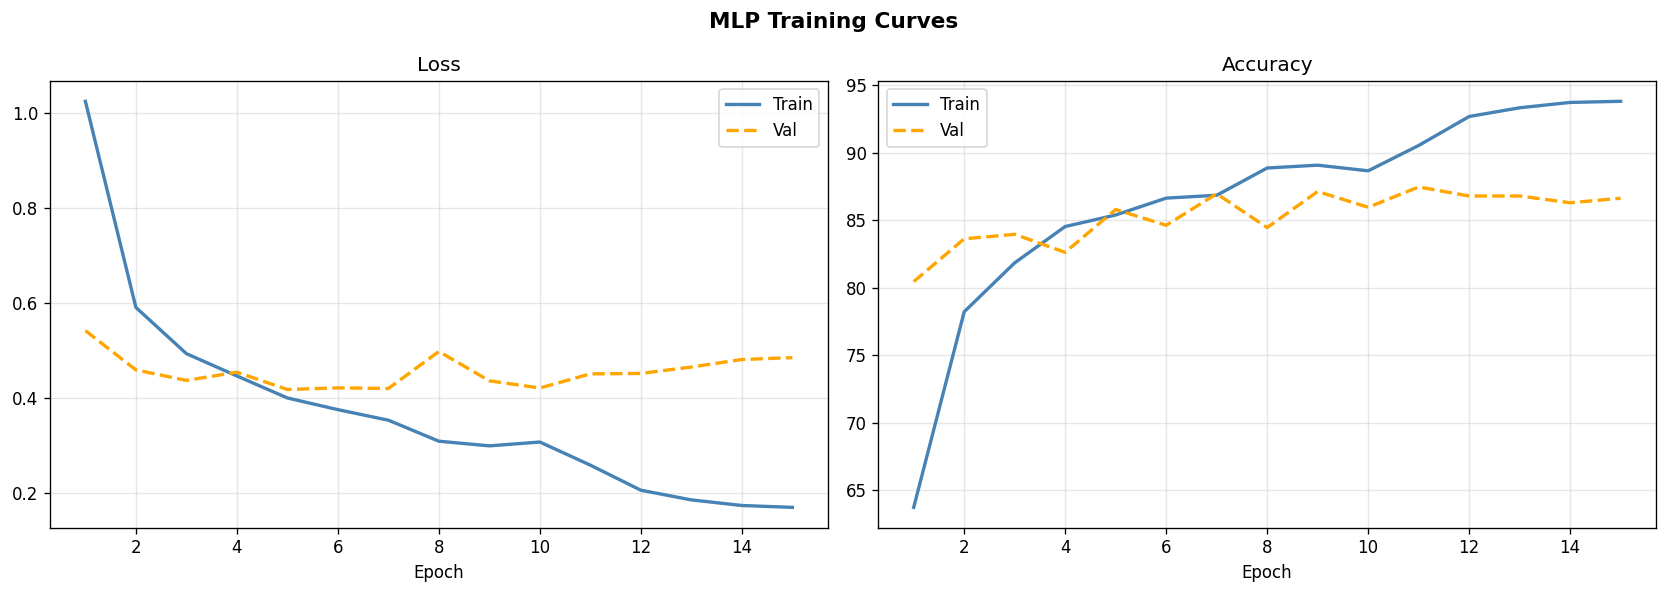

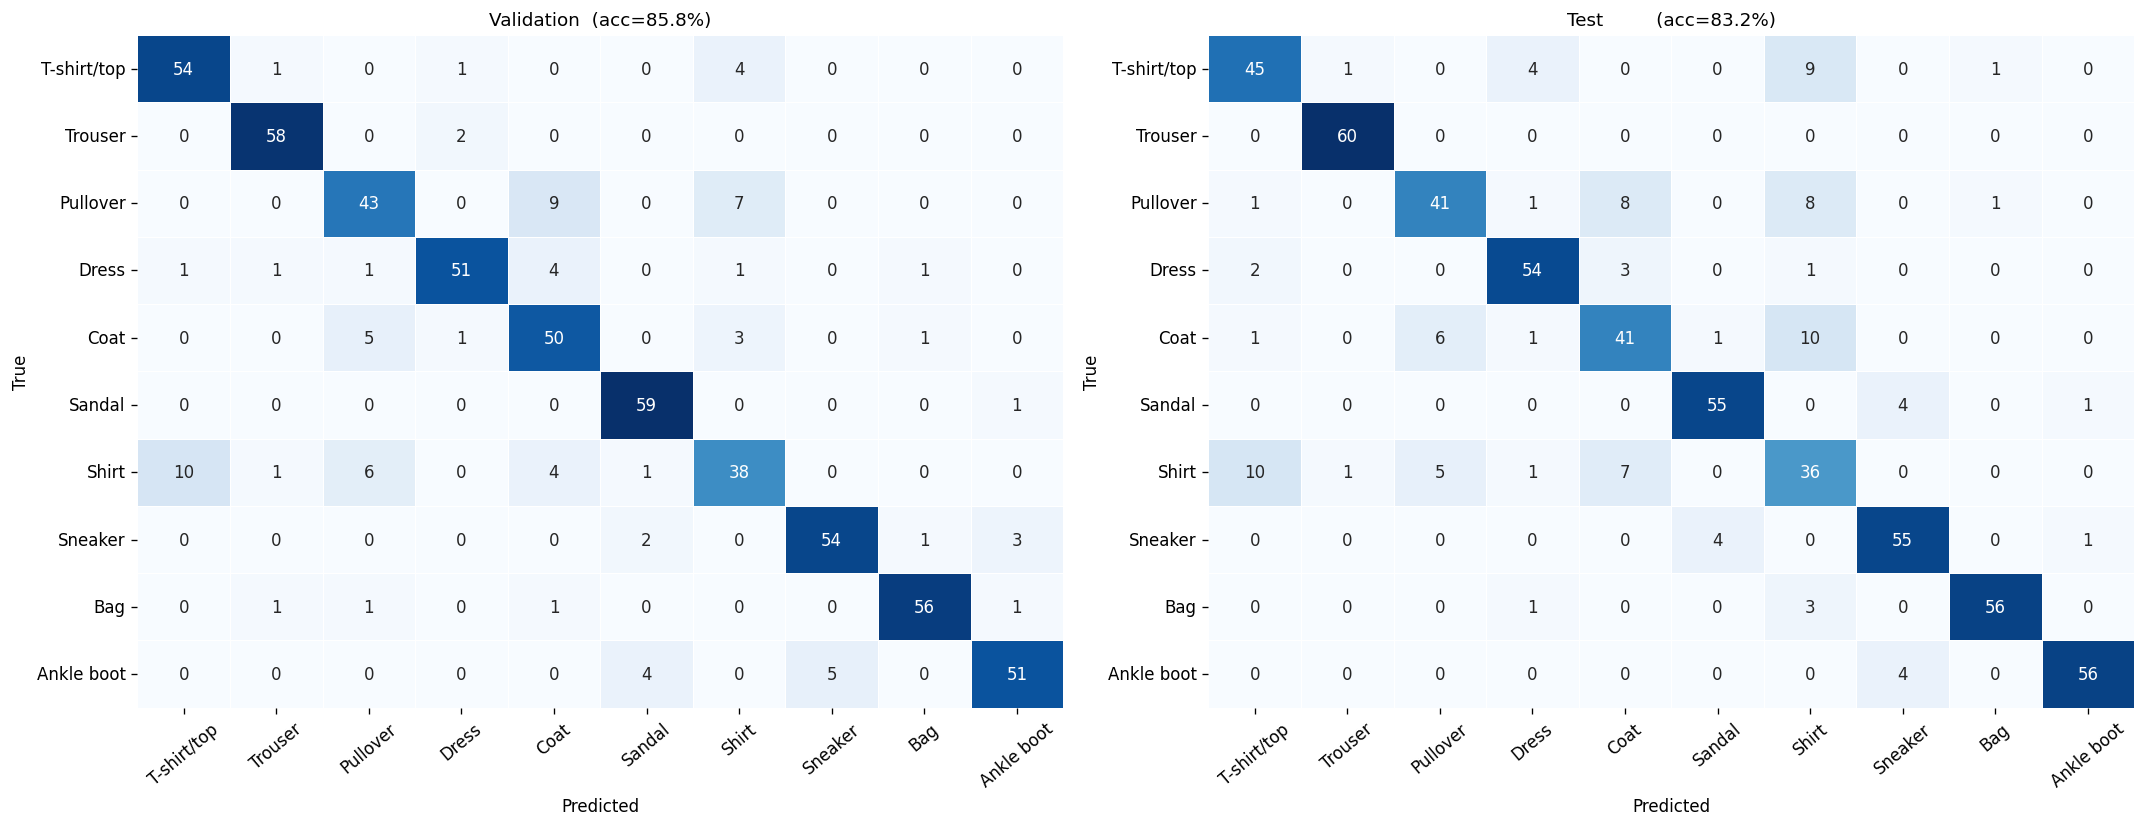

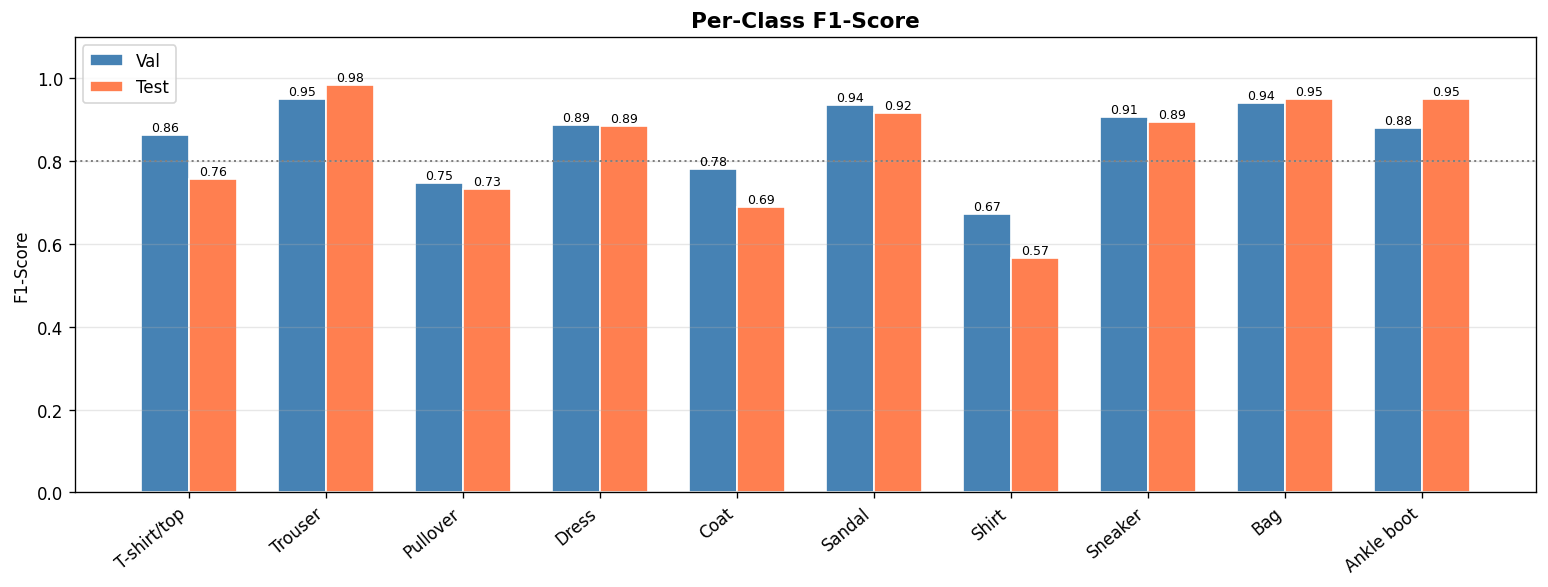

In [16]:
# Loss & Accuracy curves
epochs_ran = len(train_losses_mlp)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('MLP Training Curves', fontsize=13, fontweight='bold')
axes[0].plot(range(1,epochs_ran+1), train_losses_mlp, label='Train', color='steelblue', lw=2)
axes[0].plot(range(1,epochs_ran+1), val_losses_mlp,   label='Val',   color='orange', lw=2, linestyle='--')
axes[0].set_title('Loss'); axes[0].set_xlabel('Epoch'); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].plot(range(1,epochs_ran+1), [a*100 for a in train_accs_mlp], label='Train', color='steelblue', lw=2)
axes[1].plot(range(1,epochs_ran+1), [a*100 for a in val_accs_mlp],   label='Val',   color='orange', lw=2, linestyle='--')
axes[1].set_title('Accuracy'); axes[1].set_xlabel('Epoch'); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

# Confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
for ax, y_true, y_pred, title in [
    (axes[0], y_v_true,  y_v_pred,  f'Validation  (acc={val_acc_mlp*100:.1f}%)'),
    (axes[1], y_te_true, y_te_pred, f'Test         (acc={test_acc_mlp*100:.1f}%)')
]:
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, linewidths=0.4, cbar=False)
    ax.set_title(title, fontsize=11); ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    ax.tick_params(axis='x', rotation=40)
plt.tight_layout(); plt.show()

# Per-class F1
f1_v  = f1_score(y_v_true,  y_v_pred,  average=None)
f1_te = f1_score(y_te_true, y_te_pred, average=None)
x = np.arange(10); w = 0.35
fig, ax = plt.subplots(figsize=(13, 5))
b1 = ax.bar(x-w/2, f1_v,  w, label='Val',  color='steelblue', edgecolor='white')
b2 = ax.bar(x+w/2, f1_te, w, label='Test', color='coral',     edgecolor='white')
ax.set_xticks(x); ax.set_xticklabels(CLASS_NAMES, rotation=40, ha='right')
ax.set_ylim(0, 1.1); ax.set_ylabel('F1-Score')
ax.set_title('Per-Class F1-Score', fontsize=13, fontweight='bold')
ax.axhline(0.8, color='grey', linestyle=':', lw=1.2); ax.legend(); ax.grid(axis='y', alpha=0.3)
for bar in [*b1, *b2]:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
            f'{bar.get_height():.2f}', ha='center', fontsize=7.5)
plt.tight_layout(); plt.show()


## MLP Results — Notes

The model hit **86.48% on validation** and **83.17% on test**, which is honestly pretty good for only being trained on 10% of the data.

Some classes were a breeze — Trousers, Bags, and Sandals scored near perfectly, which makes sense since they look nothing like the other items. Ankle boots were also consistently solid.

Shirts were the real struggle, with only a 0.57 F1 on the test set. This is a known issue with Fashion MNIST — Shirts, T-shirts, Pullovers, and Coats all look very similar at 28×28 pixels and the model (understandably) gets confused between them.

The ~3% drop from validation to test is mild and nothing alarming. Training on the full dataset would likely push accuracy comfortably above 90%.


---
## 5. CNN — Golden Rules

### Helper Functions (shared across all rules)

In [17]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, Dataset
from torchvision import transforms
import numpy as np

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def make_loaders(X, y, batch_size=64):
    X_r = X.reshape(-1, 1, 28, 28).astype(np.float32) / 255.0
    X_tr, X_tmp, y_tr, y_tmp = train_test_split(X_r, y, test_size=0.20, stratify=y, random_state=42)
    X_v,  X_te,  y_v,  y_te  = train_test_split(X_tmp, y_tmp, test_size=0.50, stratify=y_tmp, random_state=42)
    def tl(X, y, sh=False):
        ds = TensorDataset(torch.tensor(X), torch.tensor(y, dtype=torch.long))
        return DataLoader(ds, batch_size=batch_size, shuffle=sh)
    print(f'Train: {len(y_tr):,} | Val: {len(y_v):,} | Test: {len(y_te):,}')
    return tl(X_tr,y_tr,True), tl(X_v,y_v), tl(X_te,y_te), X_te, y_te


def train_model(model, train_loader, val_loader, epochs=20, lr=0.001, weight_decay=0):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)
    train_losses, val_losses, train_accs, val_accs = [], [], [], []
    best_val, patience_cnt, best_state = np.inf, 0, None

    print(f"{'Epoch':>6} {'Train Loss':>12} {'Val Loss':>10} {'Train Acc':>11} {'Val Acc':>9}")
    print('-' * 55)
    for epoch in range(1, epochs+1):
        model.train(); tl, correct, total = 0, 0, 0
        for Xb, yb in train_loader:
            Xb, yb = Xb.to(device), yb.to(device)
            optimizer.zero_grad(); out = model(Xb); loss = criterion(out, yb)
            loss.backward(); optimizer.step()
            tl += loss.item()*len(yb); correct += (out.argmax(1)==yb).sum().item(); total += len(yb)
        tl /= total; ta = correct/total

        model.eval(); vl, correct, total = 0, 0, 0
        with torch.no_grad():
            for Xb, yb in val_loader:
                Xb, yb = Xb.to(device), yb.to(device)
                out = model(Xb); loss = criterion(out, yb)
                vl += loss.item()*len(yb); correct += (out.argmax(1)==yb).sum().item(); total += len(yb)
        vl /= total; va = correct/total

        train_losses.append(tl); val_losses.append(vl)
        train_accs.append(ta);   val_accs.append(va)
        scheduler.step(vl)
        print(f'{epoch:>6} {tl:>12.4f} {vl:>10.4f} {ta*100:>10.2f}% {va*100:>8.2f}%')

        if vl < best_val - 1e-4:
            best_val = vl; best_state = {k: v.clone() for k, v in model.state_dict().items()}; patience_cnt = 0
        else:
            patience_cnt += 1
            if patience_cnt >= 10: print(f'  Early stopping at epoch {epoch}'); break

    model.load_state_dict(best_state)
    print(f'\nBest val loss: {best_val:.4f}')
    return train_losses, val_losses, train_accs, val_accs


def evaluate(model, loader):
    model.eval(); preds, labels = [], []
    with torch.no_grad():
        for Xb, yb in loader:
            preds.extend(model(Xb.to(device)).argmax(1).cpu().numpy())
            labels.extend(yb.numpy())
    return np.array(labels), np.array(preds)


def plot_curves(tl, vl, ta, va, title):
    n = len(tl)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'{title} — Training Curves', fontsize=13, fontweight='bold')
    axes[0].plot(range(1,n+1), tl, label='Train', color='steelblue', lw=2)
    axes[0].plot(range(1,n+1), vl, label='Val',   color='orange',   lw=2, linestyle='--')
    axes[0].set_title('Loss'); axes[0].set_xlabel('Epoch'); axes[0].legend(); axes[0].grid(alpha=0.3)
    axes[1].plot(range(1,n+1), [a*100 for a in ta], label='Train', color='steelblue', lw=2)
    axes[1].plot(range(1,n+1), [a*100 for a in va], label='Val',   color='orange',   lw=2, linestyle='--')
    axes[1].set_title('Accuracy'); axes[1].set_xlabel('Epoch'); axes[1].legend(); axes[1].grid(alpha=0.3)
    plt.tight_layout(); plt.show()


def plot_confusion(y_true, y_pred, title, acc):
    fig, ax = plt.subplots(figsize=(10, 8))
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, linewidths=0.4, cbar=False)
    ax.set_title(f'{title}  (acc={acc*100:.1f}%)', fontsize=12, fontweight='bold')
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    ax.tick_params(axis='x', rotation=40); plt.tight_layout(); plt.show()


def full_evaluation(model, val_loader, test_loader, title):
    yv, pv = evaluate(model, val_loader)
    yt, pt = evaluate(model, test_loader)
    va = accuracy_score(yv, pv); ta = accuracy_score(yt, pt)
    print(f'\nVALIDATION — Accuracy: {va*100:.2f}%')
    print(classification_report(yv, pv, target_names=CLASS_NAMES))
    print(f'TEST — Accuracy: {ta*100:.2f}%')
    print(classification_report(yt, pt, target_names=CLASS_NAMES))
    plot_confusion(yv, pv, f'{title} — Validation', va)
    plot_confusion(yt, pt, f'{title} — Test', ta)
    return va, ta


### Naive CNN Architecture

In [18]:
class NaiveCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),                             # 28x28 → 14x14
            nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),                             # 14x14 → 7x7
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 128), nn.ReLU(),
            nn.Linear(128, 10)
        )
    def forward(self, x): return self.classifier(self.features(x))

print(NaiveCNN())
print(f'Total parameters: {sum(p.numel() for p in NaiveCNN().parameters()):,}')


NaiveCNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=3136, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=10, bias=True)
  )
)
Total parameters: 421,642


### Rule 1 — Small Set (2k), Naive CNN
Train on a tiny 2k subset to quickly check the model can learn at all.

  RULE 1 — Small Set (2k) + Naive CNN
Train: 1,600 | Val: 200 | Test: 200
 Epoch   Train Loss   Val Loss   Train Acc   Val Acc
-------------------------------------------------------
     1       1.6542     0.9745      42.88%    64.50%
     2       0.8482     0.9144      68.31%    67.00%
     3       0.7080     0.8206      73.00%    73.00%
     4       0.6294     0.6933      75.88%    73.50%
     5       0.5722     0.6738      78.81%    76.50%
     6       0.5484     0.6549      80.25%    77.50%
     7       0.5400     0.6774      79.69%    75.50%
     8       0.4761     0.5540      83.19%    81.50%
     9       0.4404     0.5807      83.94%    80.50%
    10       0.4453     0.5453      84.62%    81.00%
    11       0.3784     0.5687      86.75%    80.00%
    12       0.3507     0.5385      87.75%    83.50%
    13       0.3341     0.4695      88.19%    86.00%
    14       0.3082     0.5226      88.88%    81.50%
    15       0.2915     0.4609      89.44%    86.50%

Best val loss: 0.4609

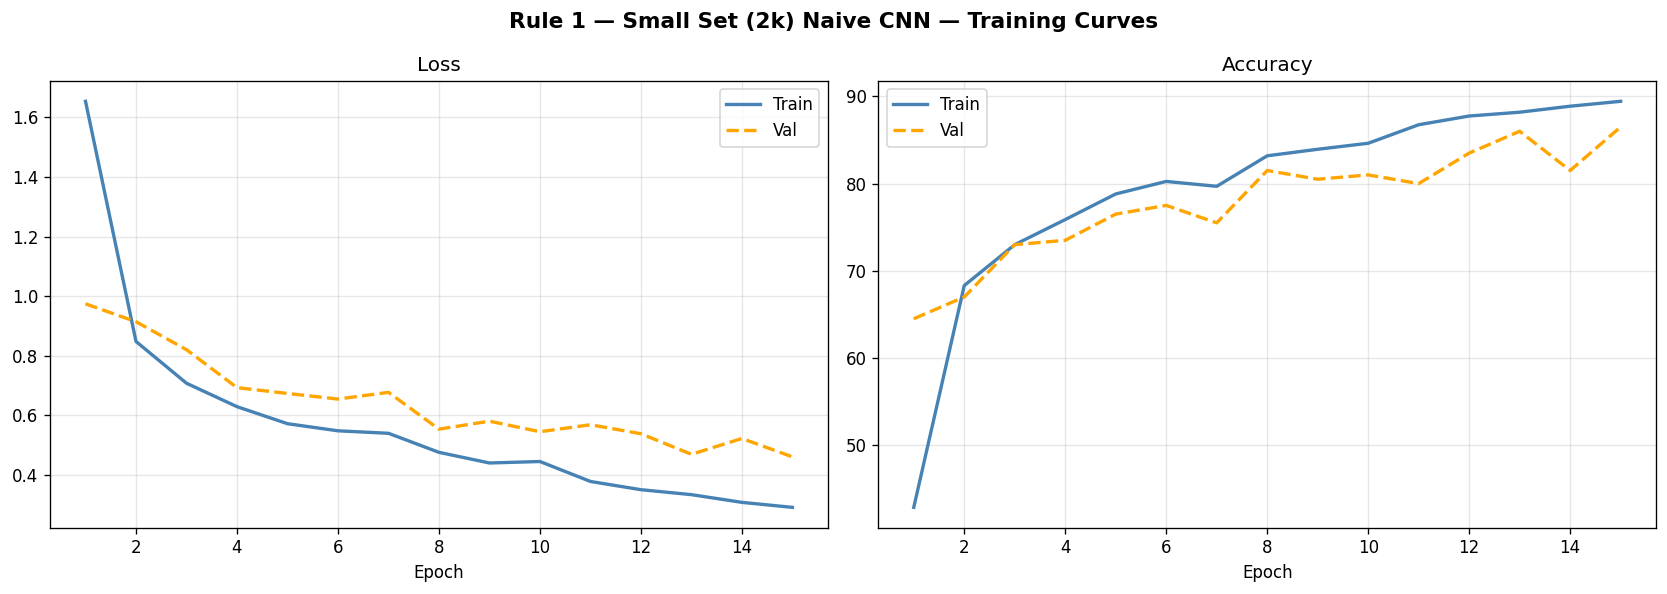


VALIDATION — Accuracy: 86.50%
              precision    recall  f1-score   support

 T-shirt/top       0.75      0.90      0.82        20
     Trouser       1.00      0.90      0.95        20
    Pullover       0.87      1.00      0.93        20
       Dress       0.74      0.85      0.79        20
        Coat       0.74      0.70      0.72        20
      Sandal       1.00      0.95      0.97        20
       Shirt       0.73      0.55      0.63        20
     Sneaker       0.87      1.00      0.93        20
         Bag       1.00      0.90      0.95        20
  Ankle boot       1.00      0.90      0.95        20

    accuracy                           0.86       200
   macro avg       0.87      0.86      0.86       200
weighted avg       0.87      0.86      0.86       200

TEST — Accuracy: 84.00%
              precision    recall  f1-score   support

 T-shirt/top       0.77      0.85      0.81        20
     Trouser       0.95      1.00      0.98        20
    Pullover       0.82

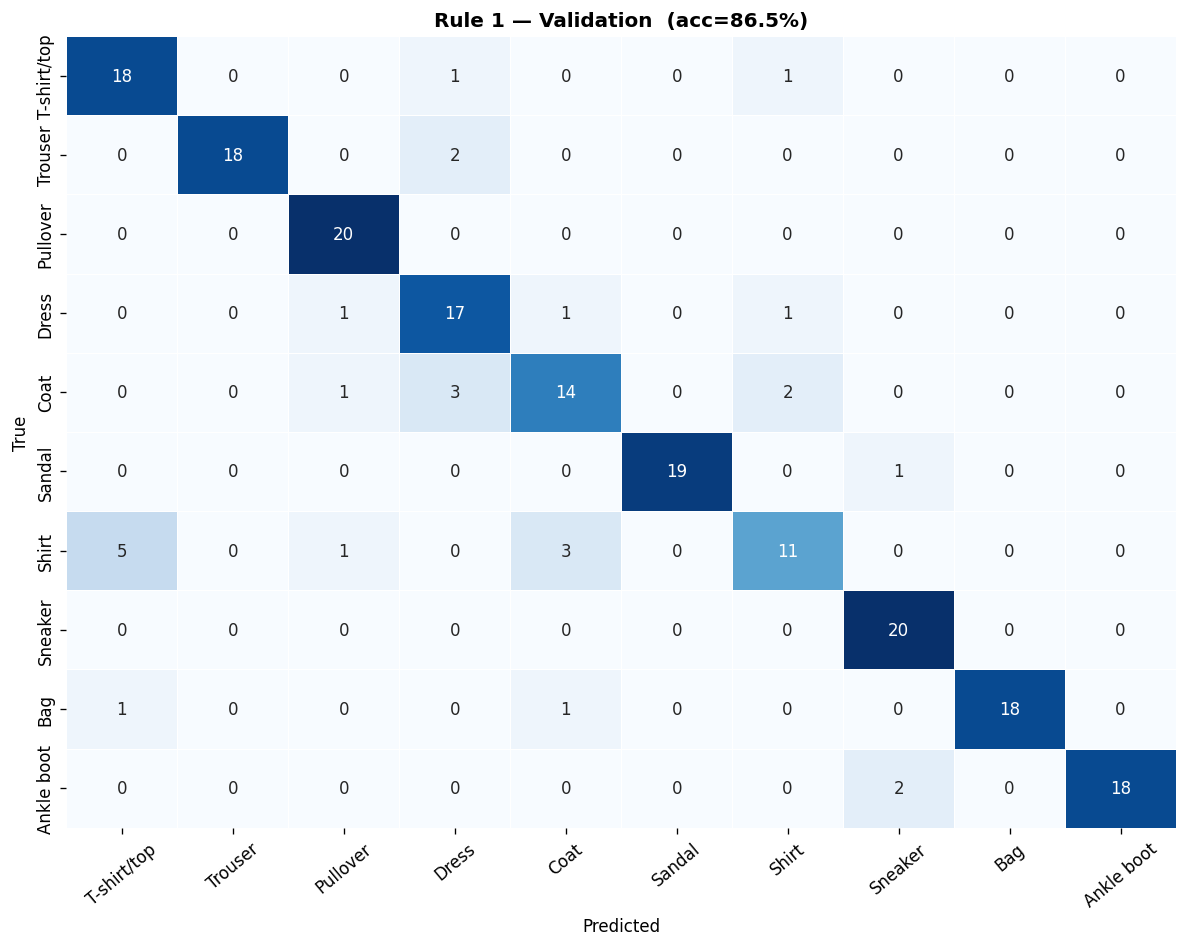

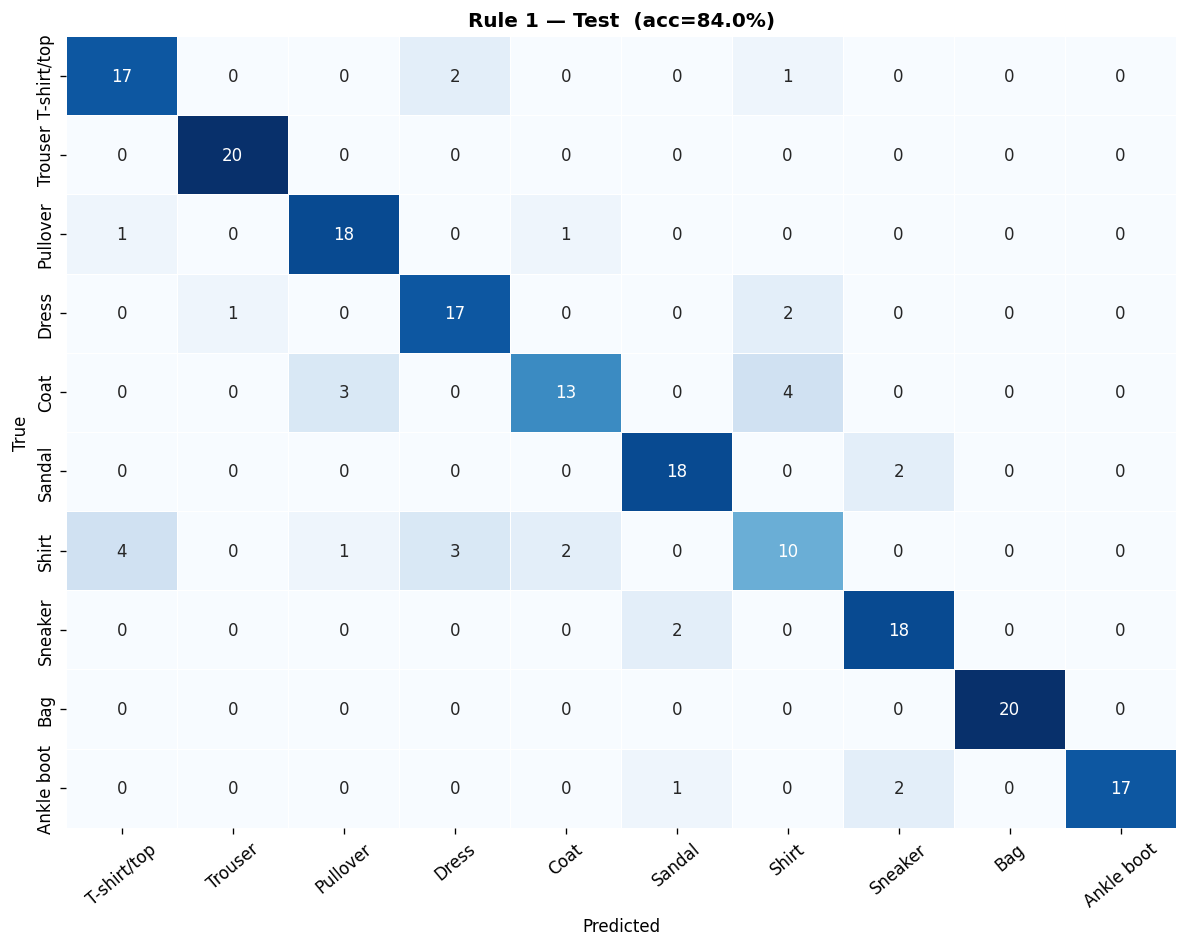

In [19]:
print('=' * 55)
print('  RULE 1 — Small Set (2k) + Naive CNN')
print('=' * 55)

X_sample = np.load('X_sample.npy')
y_sample = np.load('y_sample.npy')

# Stratified 2k subset for fast iteration
X_2k, _, y_2k, _ = train_test_split(X_sample, y_sample, train_size=2000,
                                      stratify=y_sample, random_state=42)

train_loader_s, val_loader_s, test_loader_s, X_test_s, y_test_s = make_loaders(X_2k, y_2k)

torch.manual_seed(42)
model_r1 = NaiveCNN().to(device)
losses_r1 = train_model(model_r1, train_loader_s, val_loader_s, epochs=15)
plot_curves(*losses_r1, title='Rule 1 — Small Set (2k) Naive CNN')
val_acc_r1, test_acc_r1 = full_evaluation(model_r1, val_loader_s, test_loader_s, 'Rule 1')


### Rule 2 — Full Sample (7k), Same Naive CNN
Same architecture, more data — expect a clear accuracy jump.

  RULE 2 — Medium Set (7k) + Naive CNN
Train: 4,796 | Val: 599 | Test: 600
 Epoch   Train Loss   Val Loss   Train Acc   Val Acc
-------------------------------------------------------
     1       1.0893     0.6029      60.22%    76.63%
     2       0.6072     0.4898      78.36%    82.80%
     3       0.5111     0.4492      81.30%    83.81%
     4       0.4657     0.4738      82.82%    82.47%
     5       0.4010     0.4250      85.63%    83.97%
     6       0.3812     0.4220      85.99%    84.14%
     7       0.3444     0.3733      87.51%    85.31%
     8       0.3120     0.3839      88.47%    86.48%
     9       0.2902     0.4673      89.18%    83.47%
    10       0.2890     0.3503      89.43%    87.81%
    11       0.2581     0.3779      90.58%    86.31%
    12       0.2494     0.3966      90.76%    87.31%
    13       0.2208     0.3797      92.08%    87.48%
    14       0.2007     0.3925      92.93%    86.31%
    15       0.1915     0.3779      93.18%    87.98%
    16       0.1766  

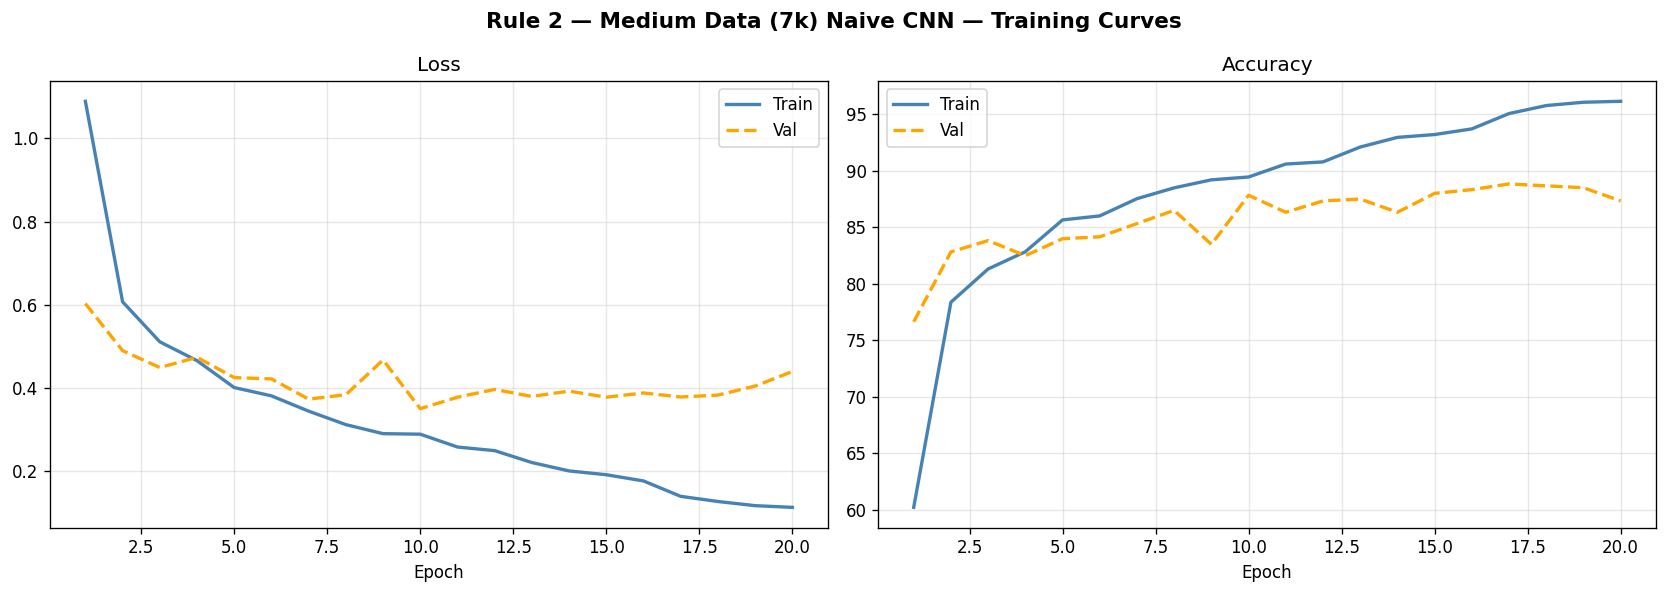


VALIDATION — Accuracy: 87.81%
              precision    recall  f1-score   support

 T-shirt/top       0.81      0.92      0.86        60
     Trouser       0.98      0.98      0.98        60
    Pullover       0.80      0.80      0.80        59
       Dress       0.82      0.93      0.88        60
        Coat       0.77      0.82      0.79        60
      Sandal       0.95      0.98      0.97        60
       Shirt       0.72      0.52      0.60        60
     Sneaker       0.96      0.92      0.94        60
         Bag       1.00      0.95      0.97        60
  Ankle boot       0.95      0.97      0.96        60

    accuracy                           0.88       599
   macro avg       0.88      0.88      0.87       599
weighted avg       0.88      0.88      0.87       599

TEST — Accuracy: 87.50%
              precision    recall  f1-score   support

 T-shirt/top       0.77      0.83      0.80        60
     Trouser       0.95      1.00      0.98        60
    Pullover       0.85

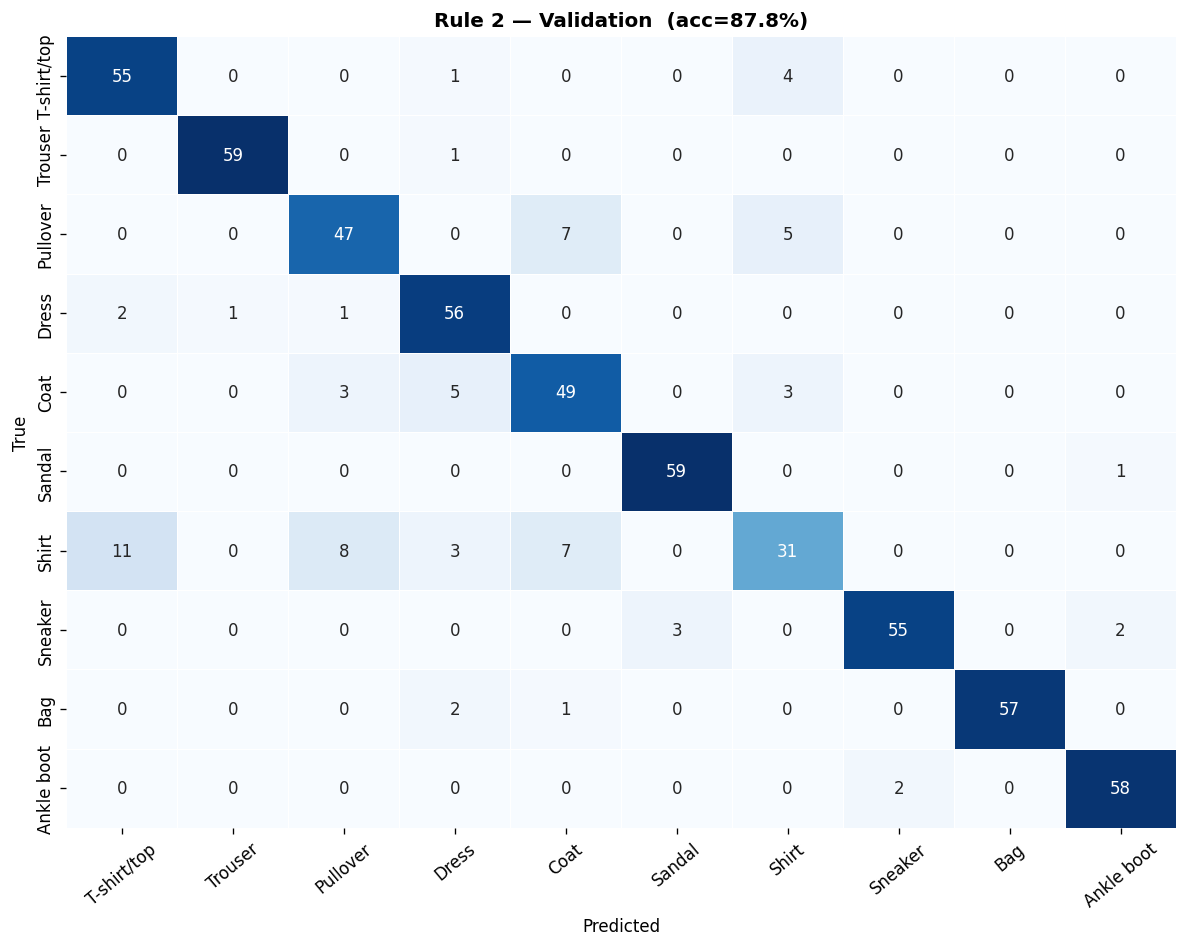

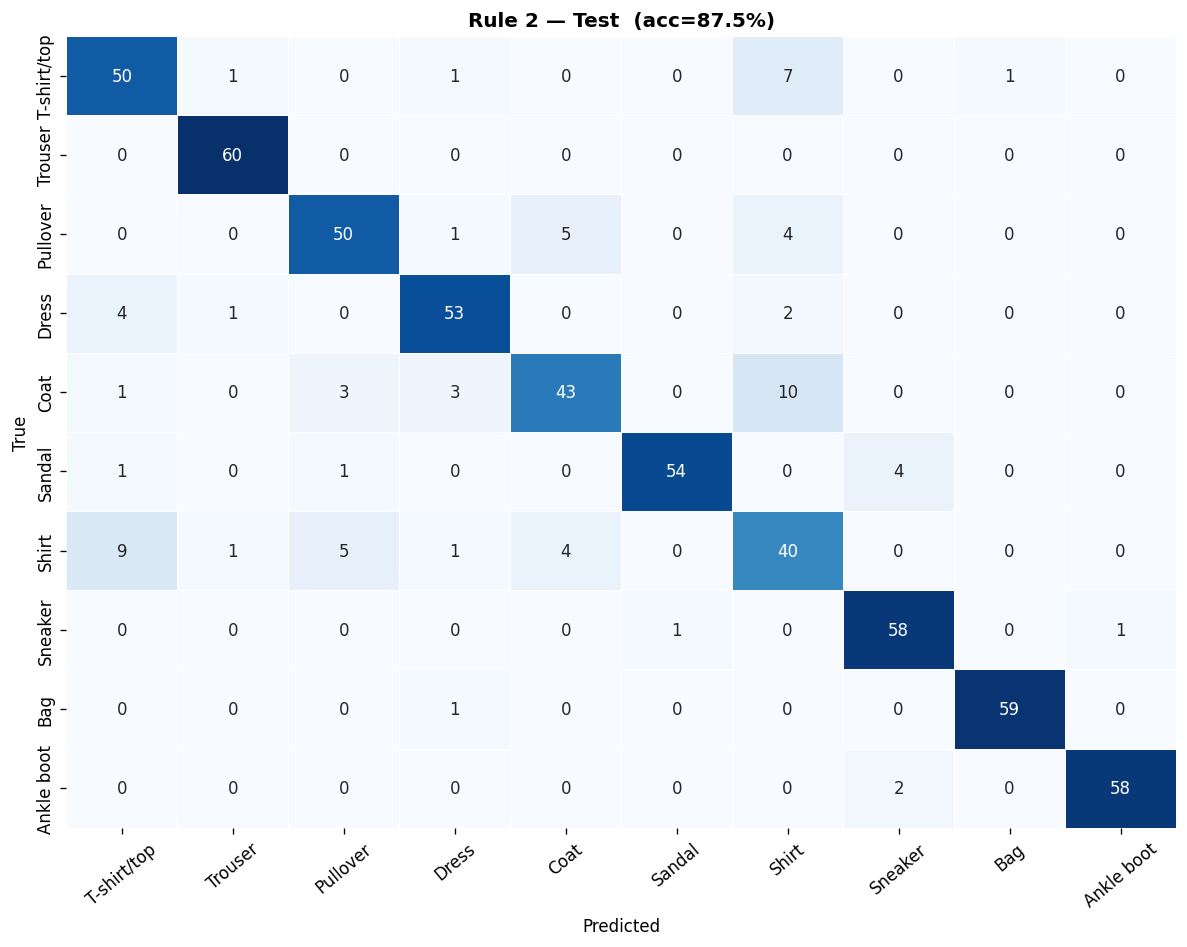

In [20]:
print('=' * 55)
print('  RULE 2 — Medium Set (7k) + Naive CNN')
print('=' * 55)

train_loader_f, val_loader_f, test_loader_f, X_test_f, y_test_f = make_loaders(X_sample, y_sample)

torch.manual_seed(42)
model_r2 = NaiveCNN().to(device)
losses_r2 = train_model(model_r2, train_loader_f, val_loader_f, epochs=20)
plot_curves(*losses_r2, title='Rule 2 — Medium Data (7k) Naive CNN')
val_acc_r2, test_acc_r2 = full_evaluation(model_r2, val_loader_f, test_loader_f, 'Rule 2')


### Rule 3 — Full Sample (7k), Deeper Naive CNN
Same data, bigger model — check if capacity helps.

  RULE 3 — Medium Data (7k) + Deeper Naive CNN
DeeperNaiveCNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU()
    (7): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU()
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=3136, out_features=256, bias=True)
    (2): ReLU()
    (3): Linear(in_features=256, out_features=128, bias=True)
    (4): ReLU()
    (5): Linear(in_features=128, out_features=10, bias=True)
  )
)
Total parameters: 902,250
 Epoch   Train Loss   Val Loss   Train Acc   Val Acc
---

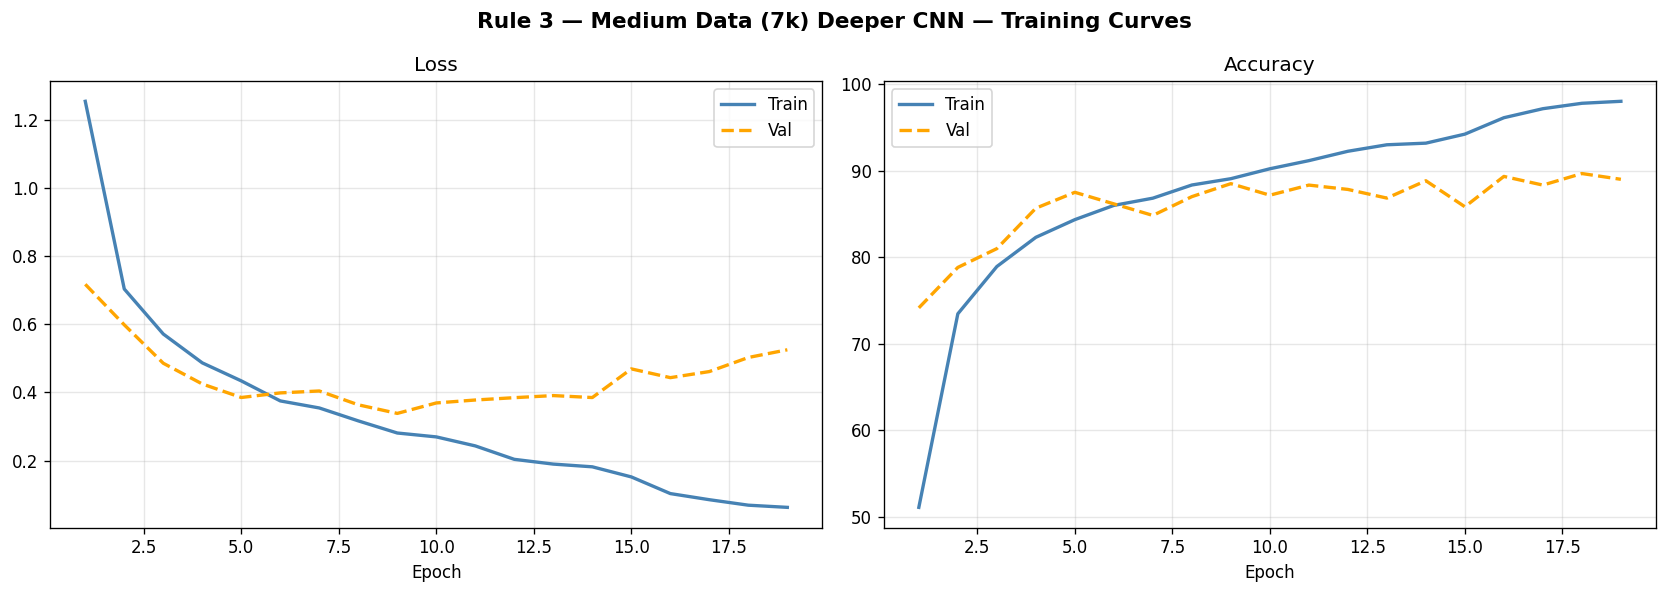


VALIDATION — Accuracy: 88.48%
              precision    recall  f1-score   support

 T-shirt/top       0.83      0.95      0.88        60
     Trouser       0.97      0.97      0.97        60
    Pullover       0.76      0.80      0.78        59
       Dress       0.93      0.93      0.93        60
        Coat       0.76      0.87      0.81        60
      Sandal       0.94      0.98      0.96        60
       Shirt       0.74      0.53      0.62        60
     Sneaker       0.95      0.95      0.95        60
         Bag       1.00      0.92      0.96        60
  Ankle boot       0.97      0.95      0.96        60

    accuracy                           0.88       599
   macro avg       0.88      0.88      0.88       599
weighted avg       0.88      0.88      0.88       599

TEST — Accuracy: 87.50%
              precision    recall  f1-score   support

 T-shirt/top       0.75      0.85      0.80        60
     Trouser       1.00      1.00      1.00        60
    Pullover       0.87

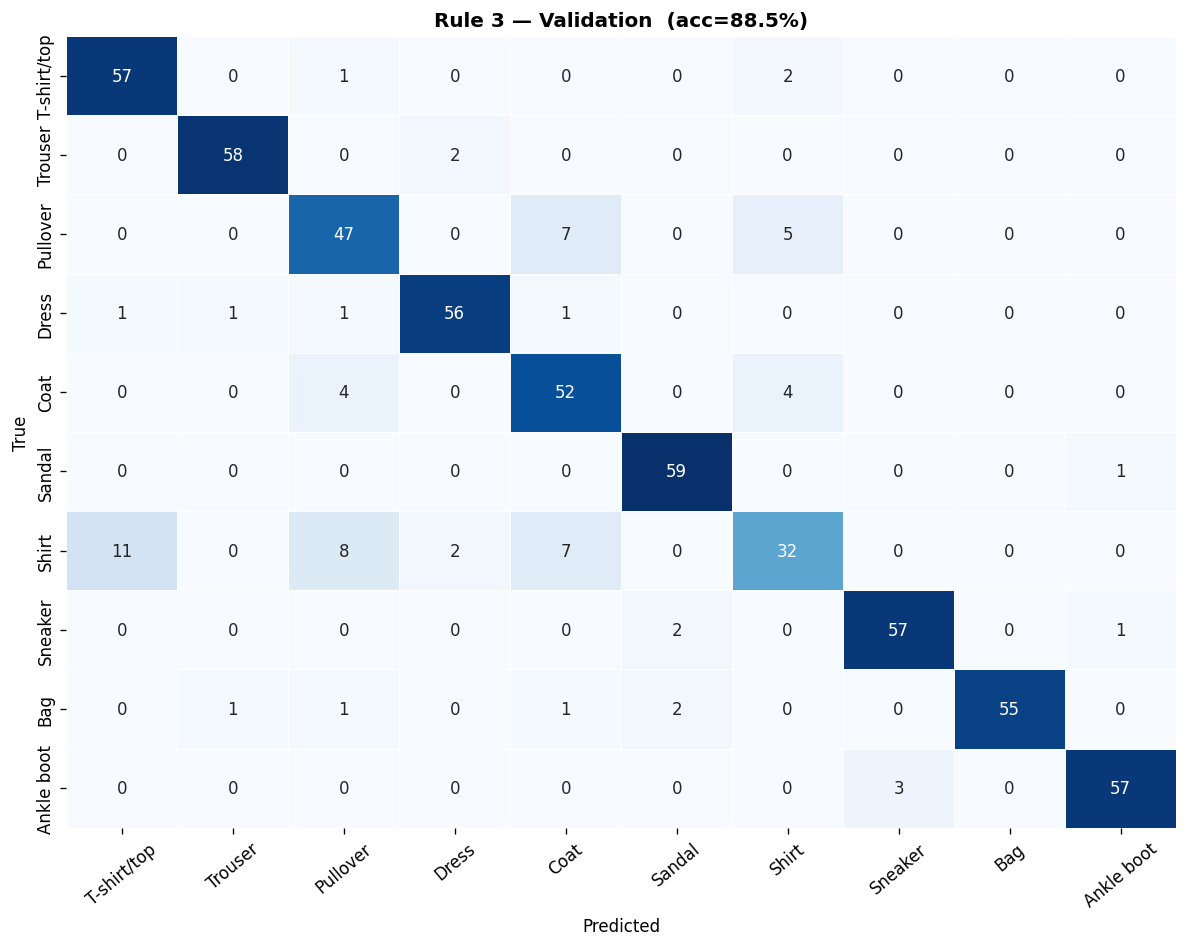

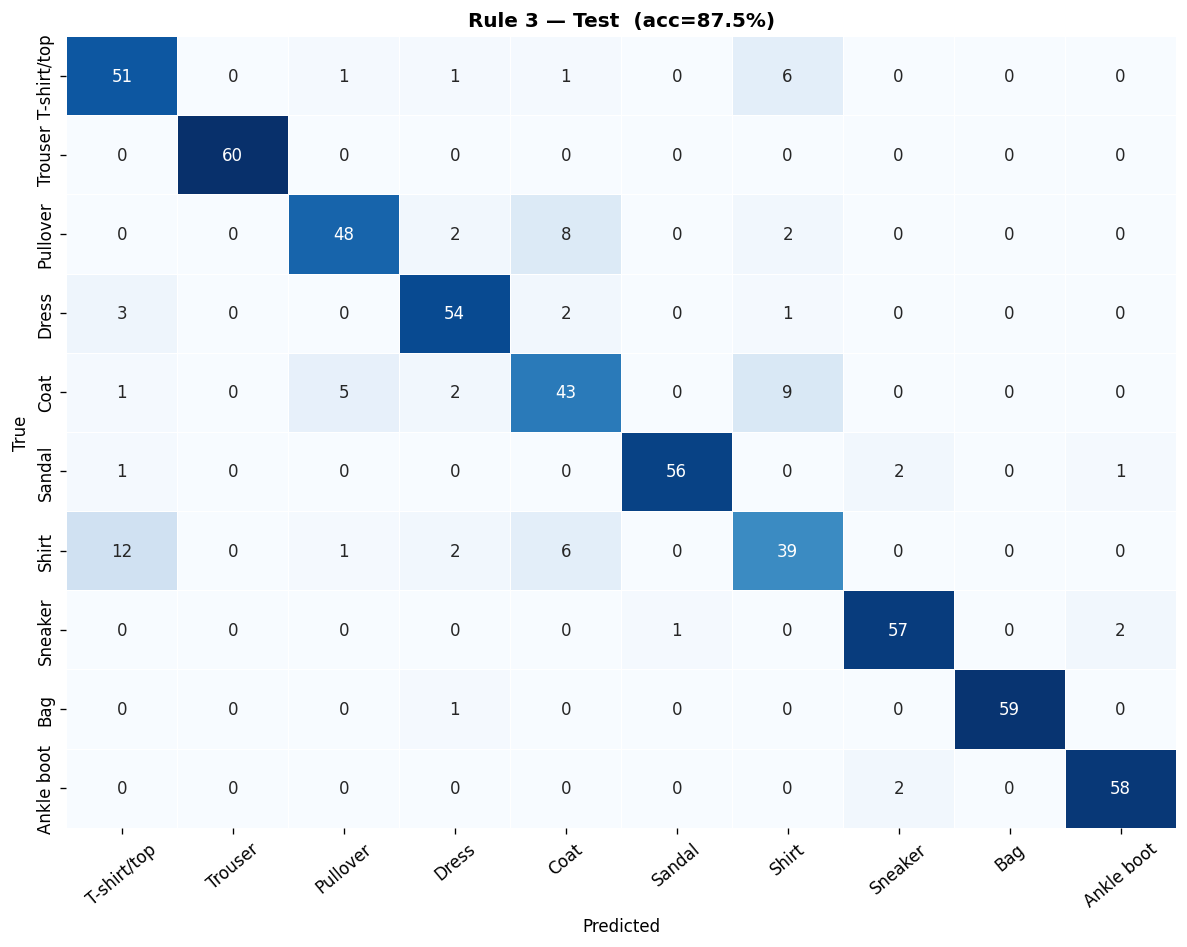

In [21]:
class DeeperNaiveCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1,  32, kernel_size=3, padding=1), nn.ReLU(),
            nn.Conv2d(32, 32, kernel_size=3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 256), nn.ReLU(),
            nn.Linear(256, 128),        nn.ReLU(),
            nn.Linear(128, 10)
        )
    def forward(self, x): return self.classifier(self.features(x))

print('=' * 55)
print('  RULE 3 — Medium Data (7k) + Deeper Naive CNN')
print('=' * 55)
print(DeeperNaiveCNN())
print(f'Total parameters: {sum(p.numel() for p in DeeperNaiveCNN().parameters()):,}')

torch.manual_seed(42)
model_r3 = DeeperNaiveCNN().to(device)
losses_r3 = train_model(model_r3, train_loader_f, val_loader_f, epochs=20)
plot_curves(*losses_r3, title='Rule 3 — Medium Data (7k) Deeper CNN')
val_acc_r3, test_acc_r3 = full_evaluation(model_r3, val_loader_f, test_loader_f, 'Rule 3')



  CNN Feature Map & Filter Visualization
Sample image class: Pullover

--- Conv2d Layer Filters ---


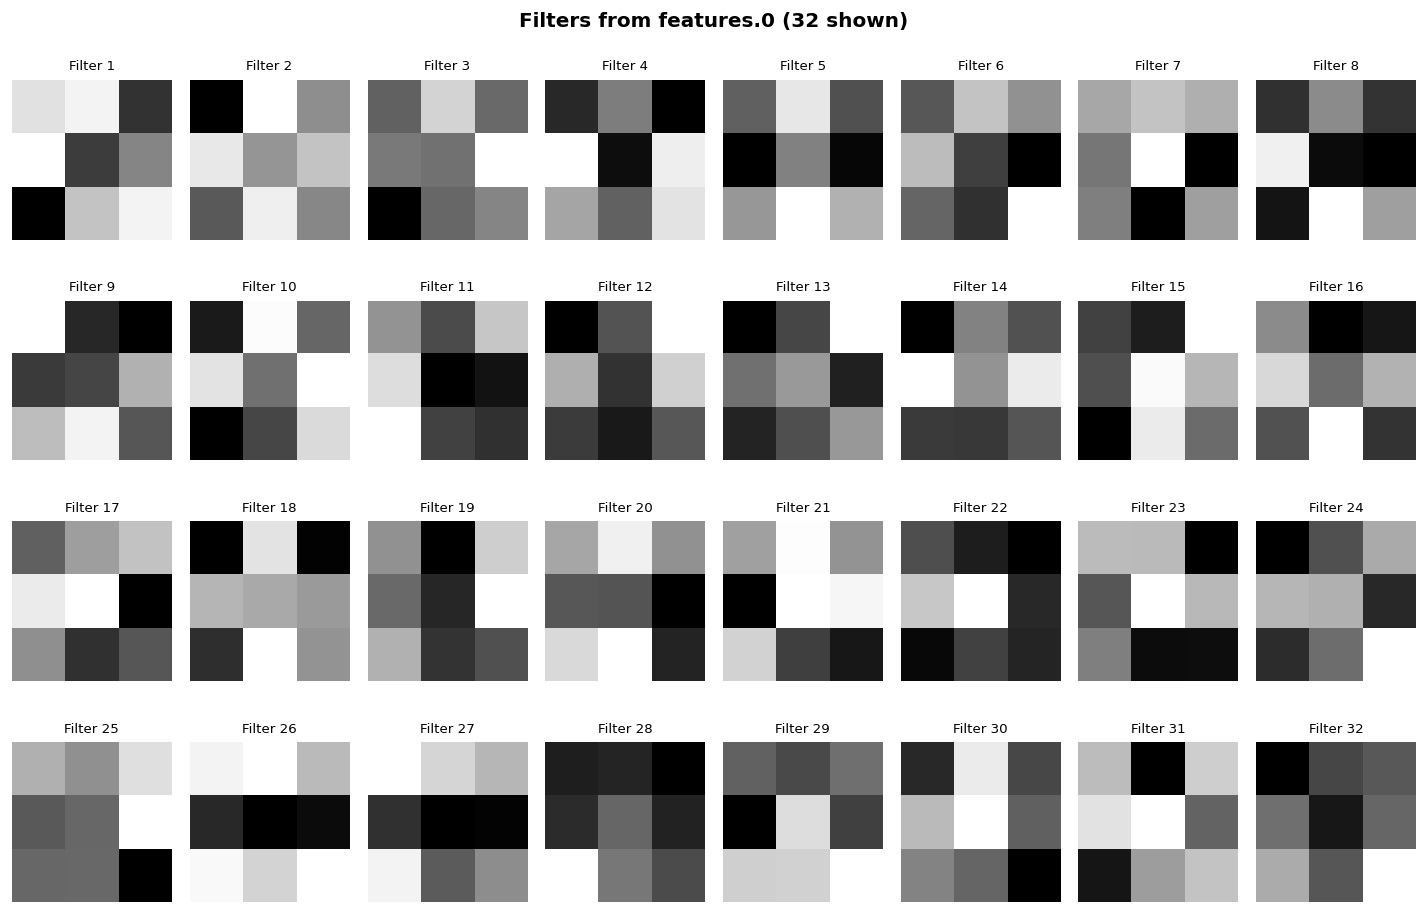

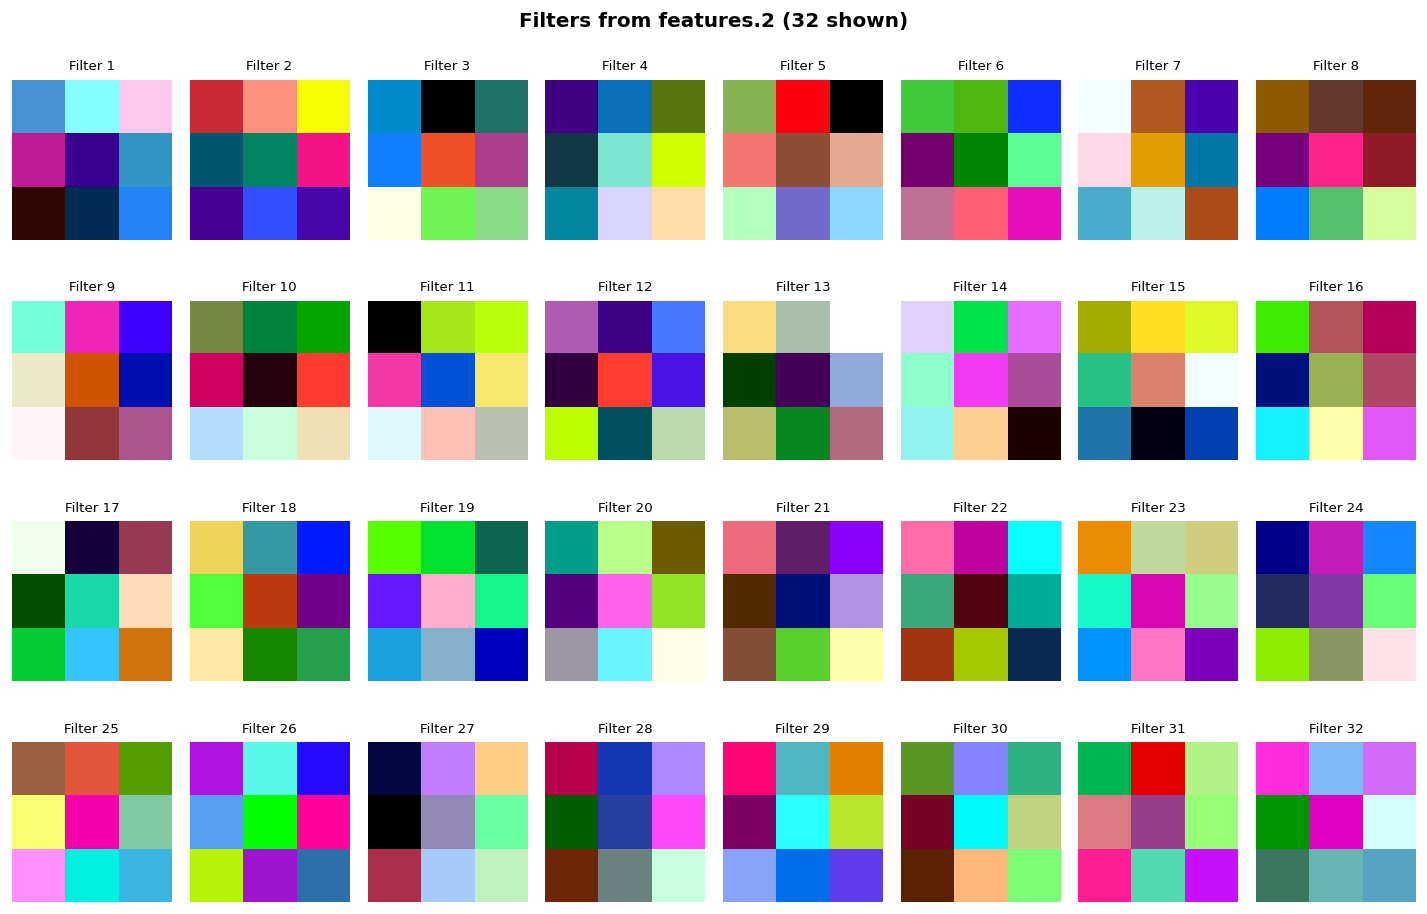

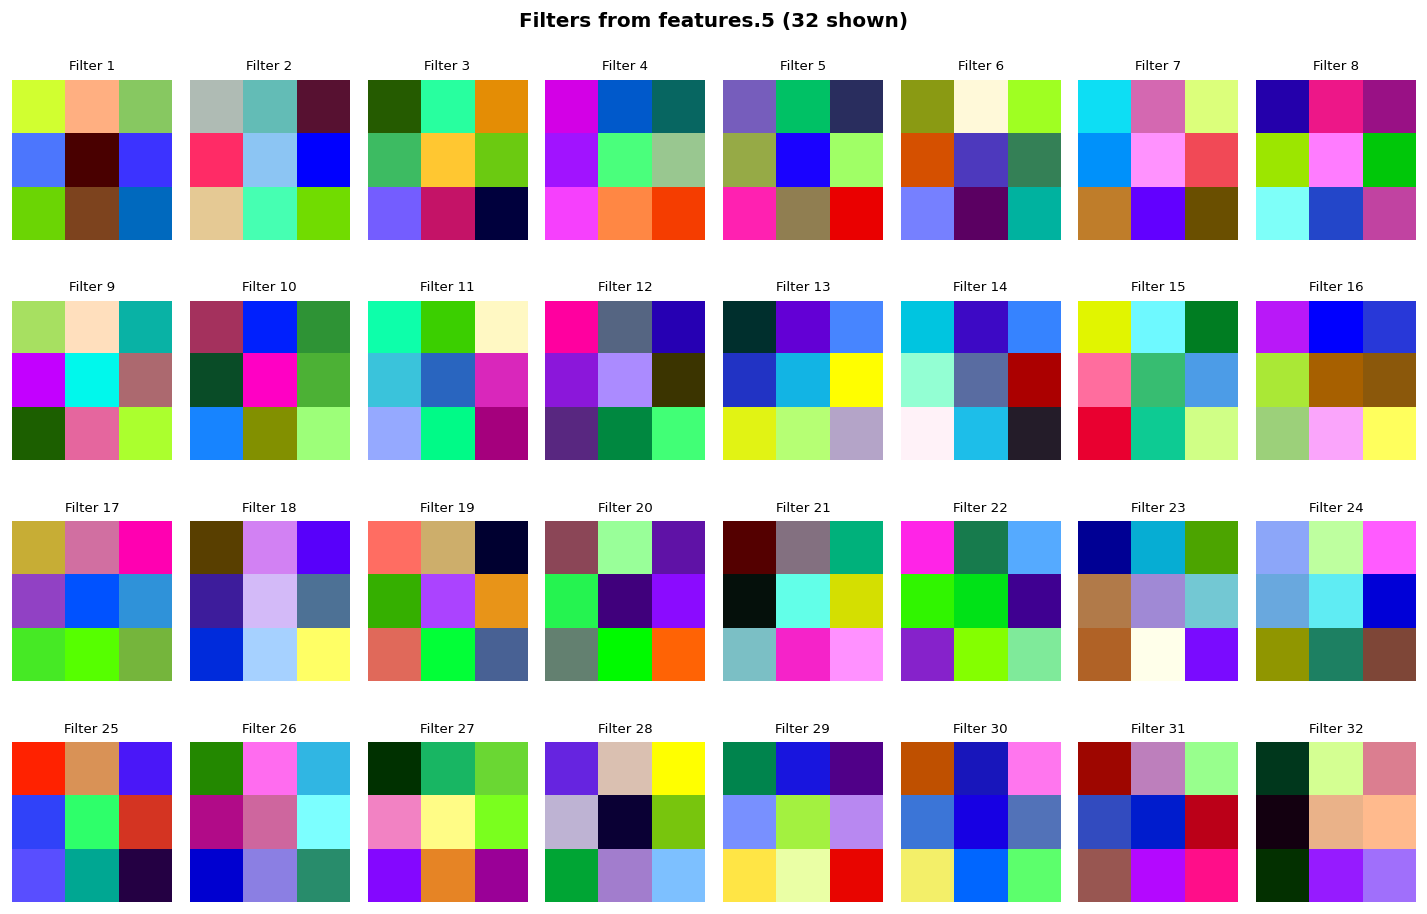

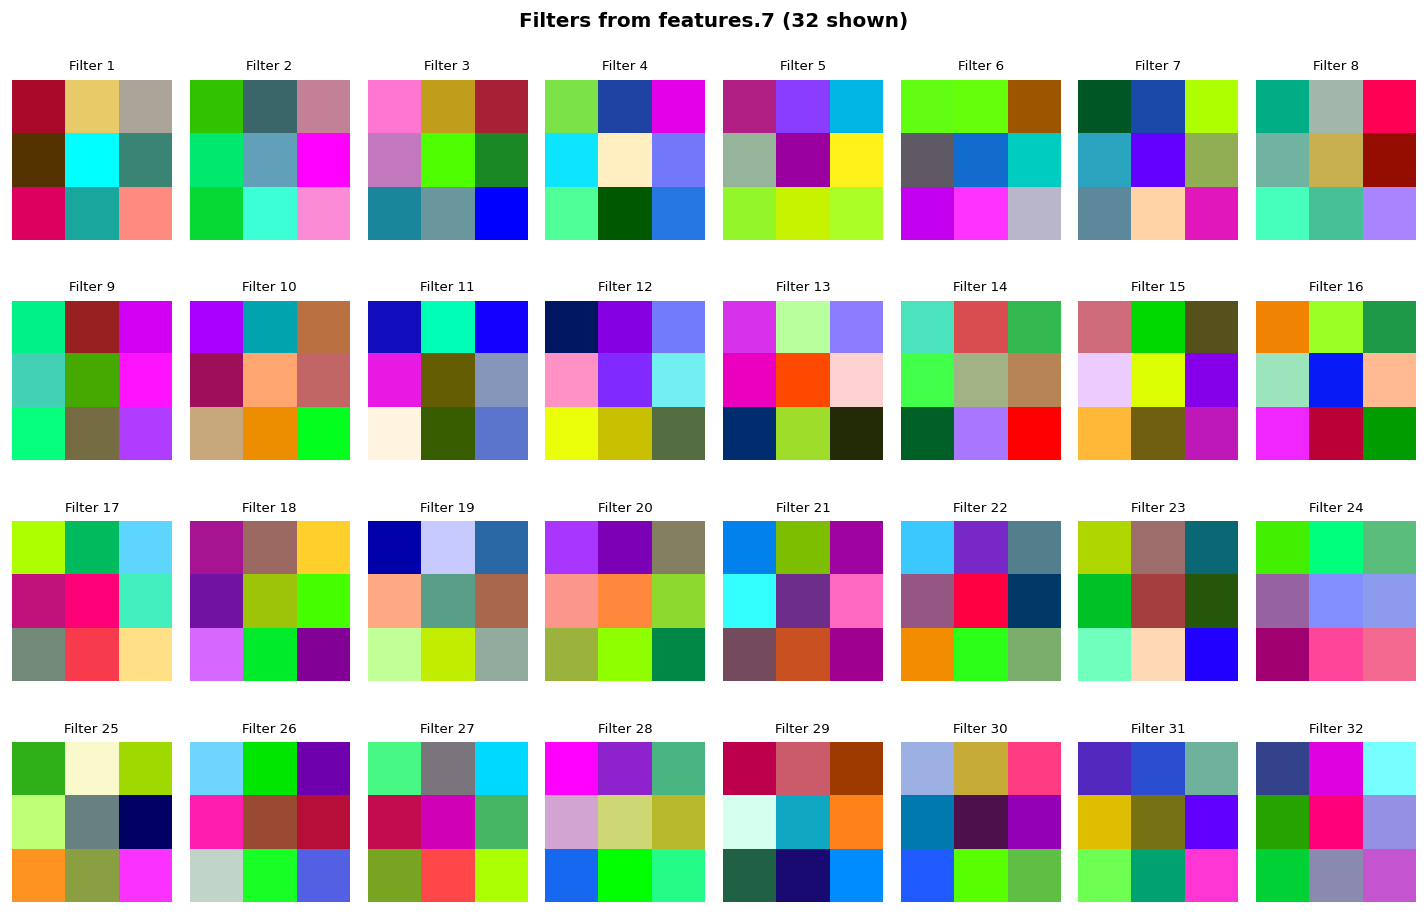


--- Feature Maps at Different Layers ---


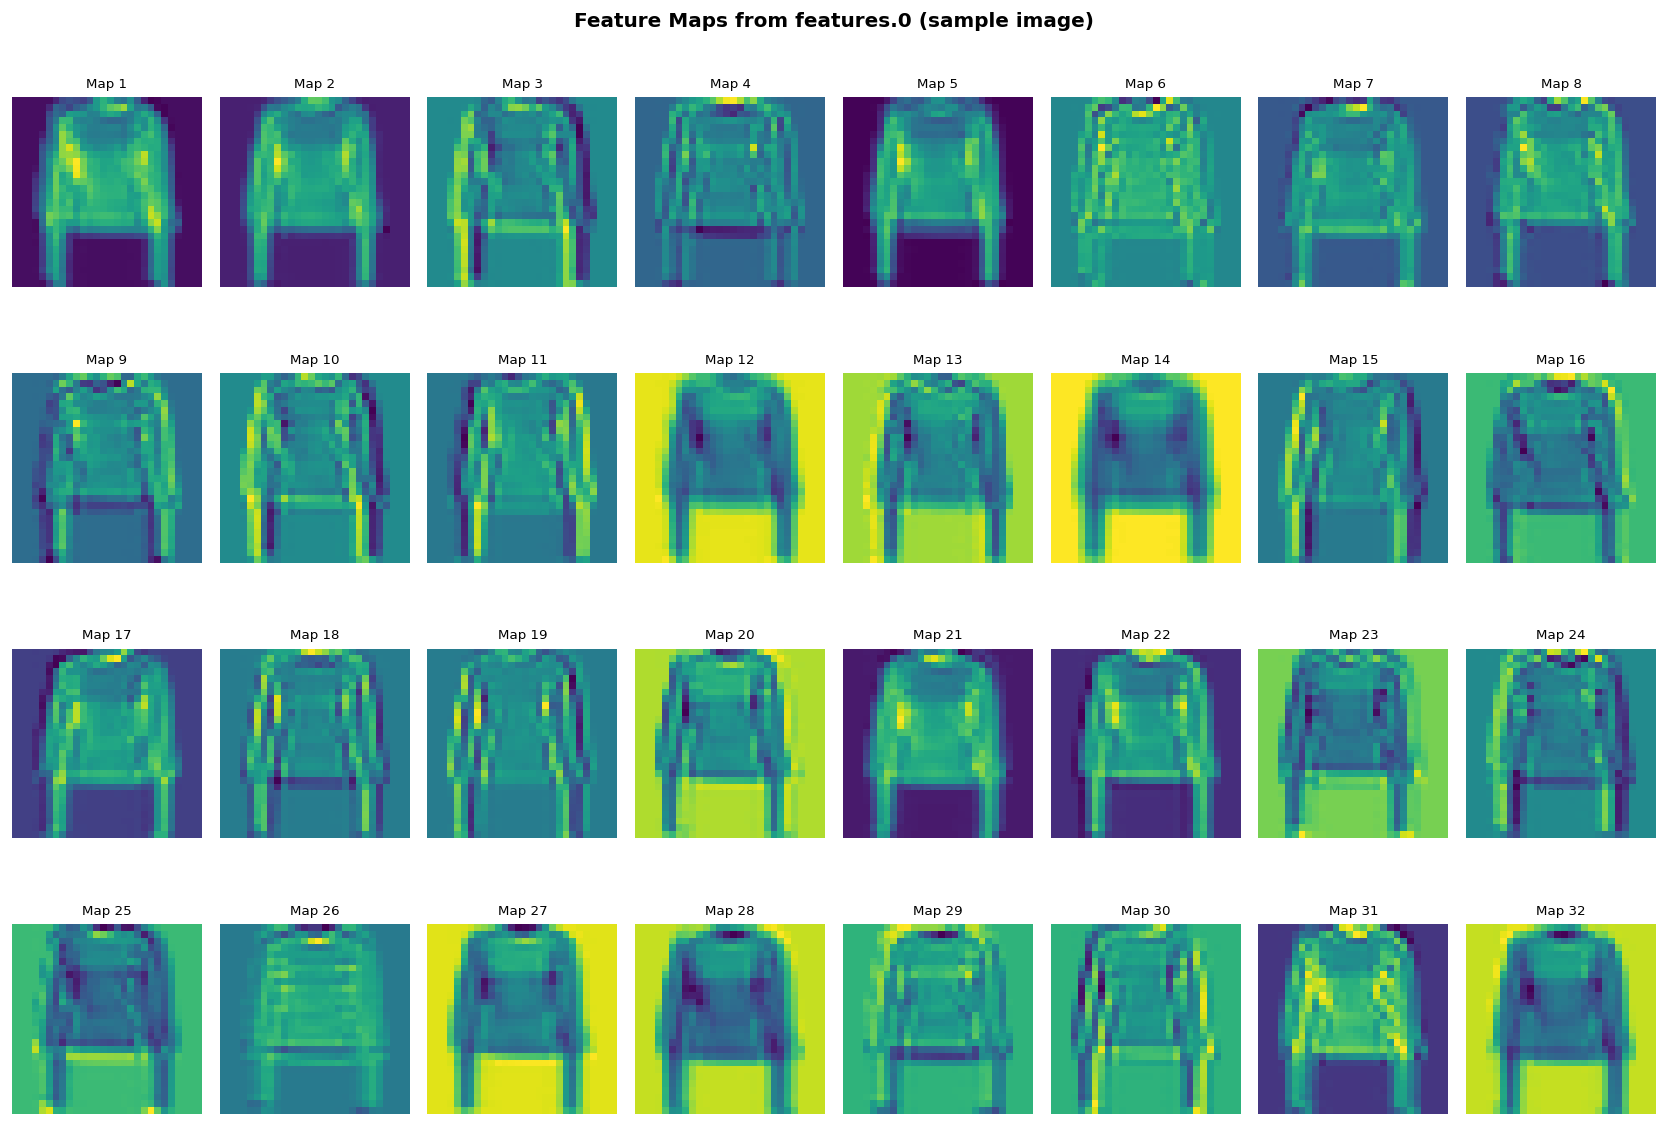

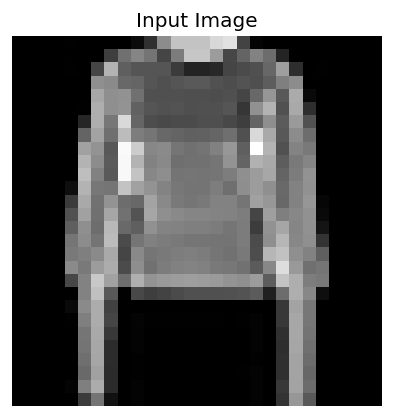

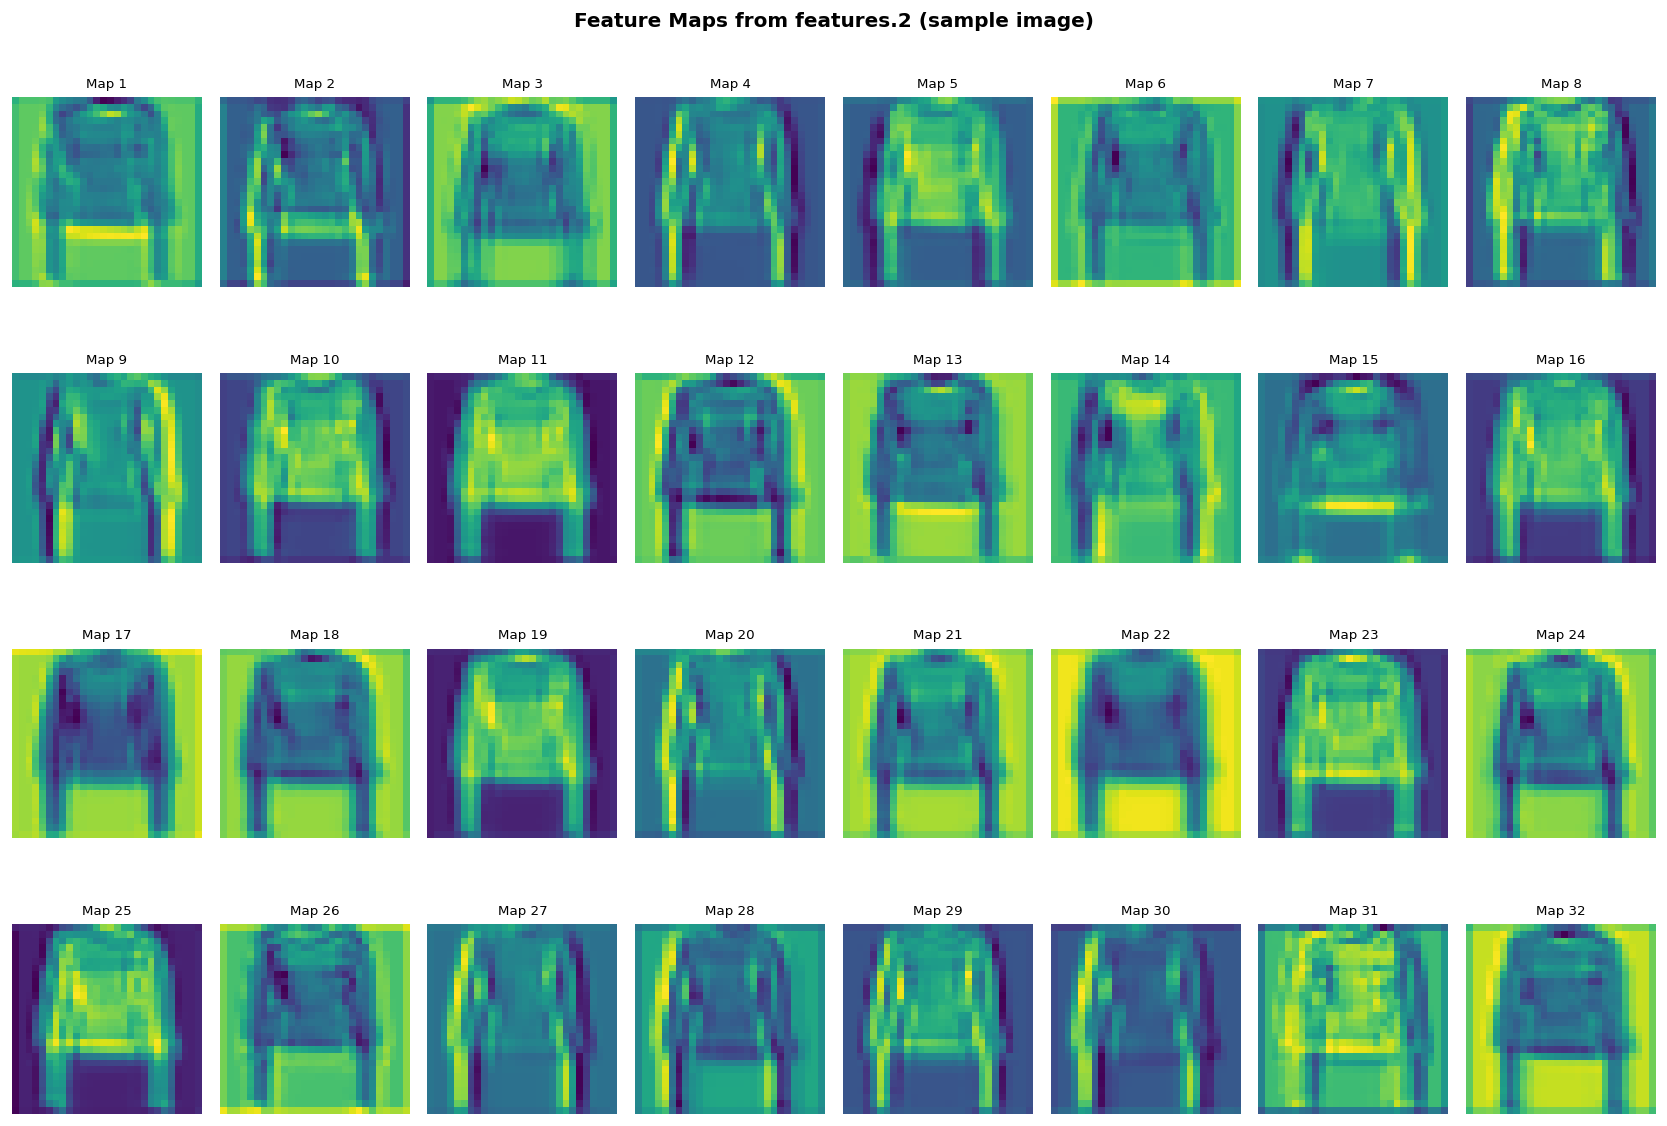

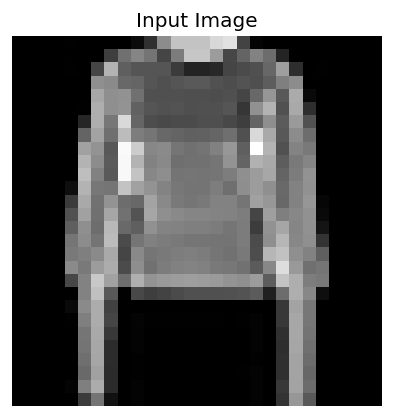

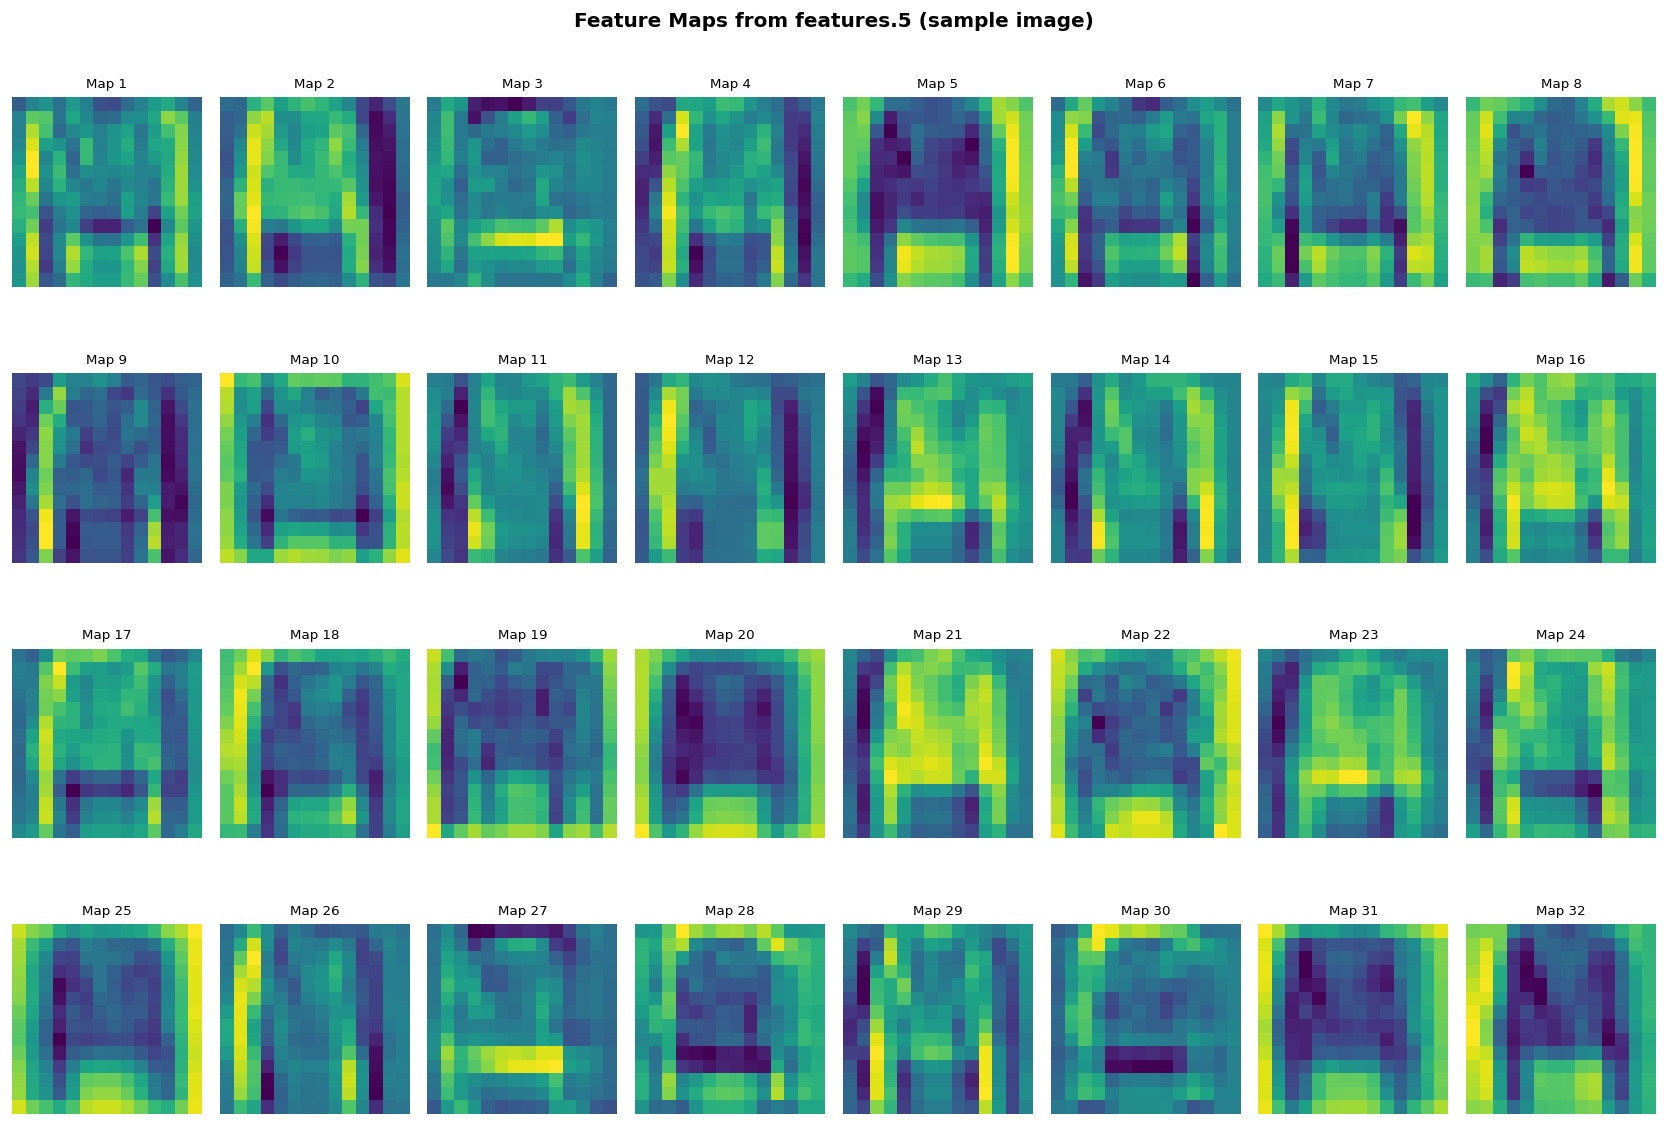

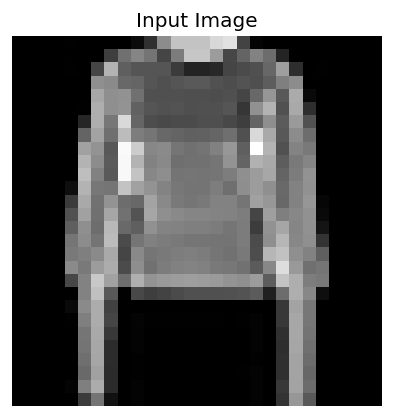

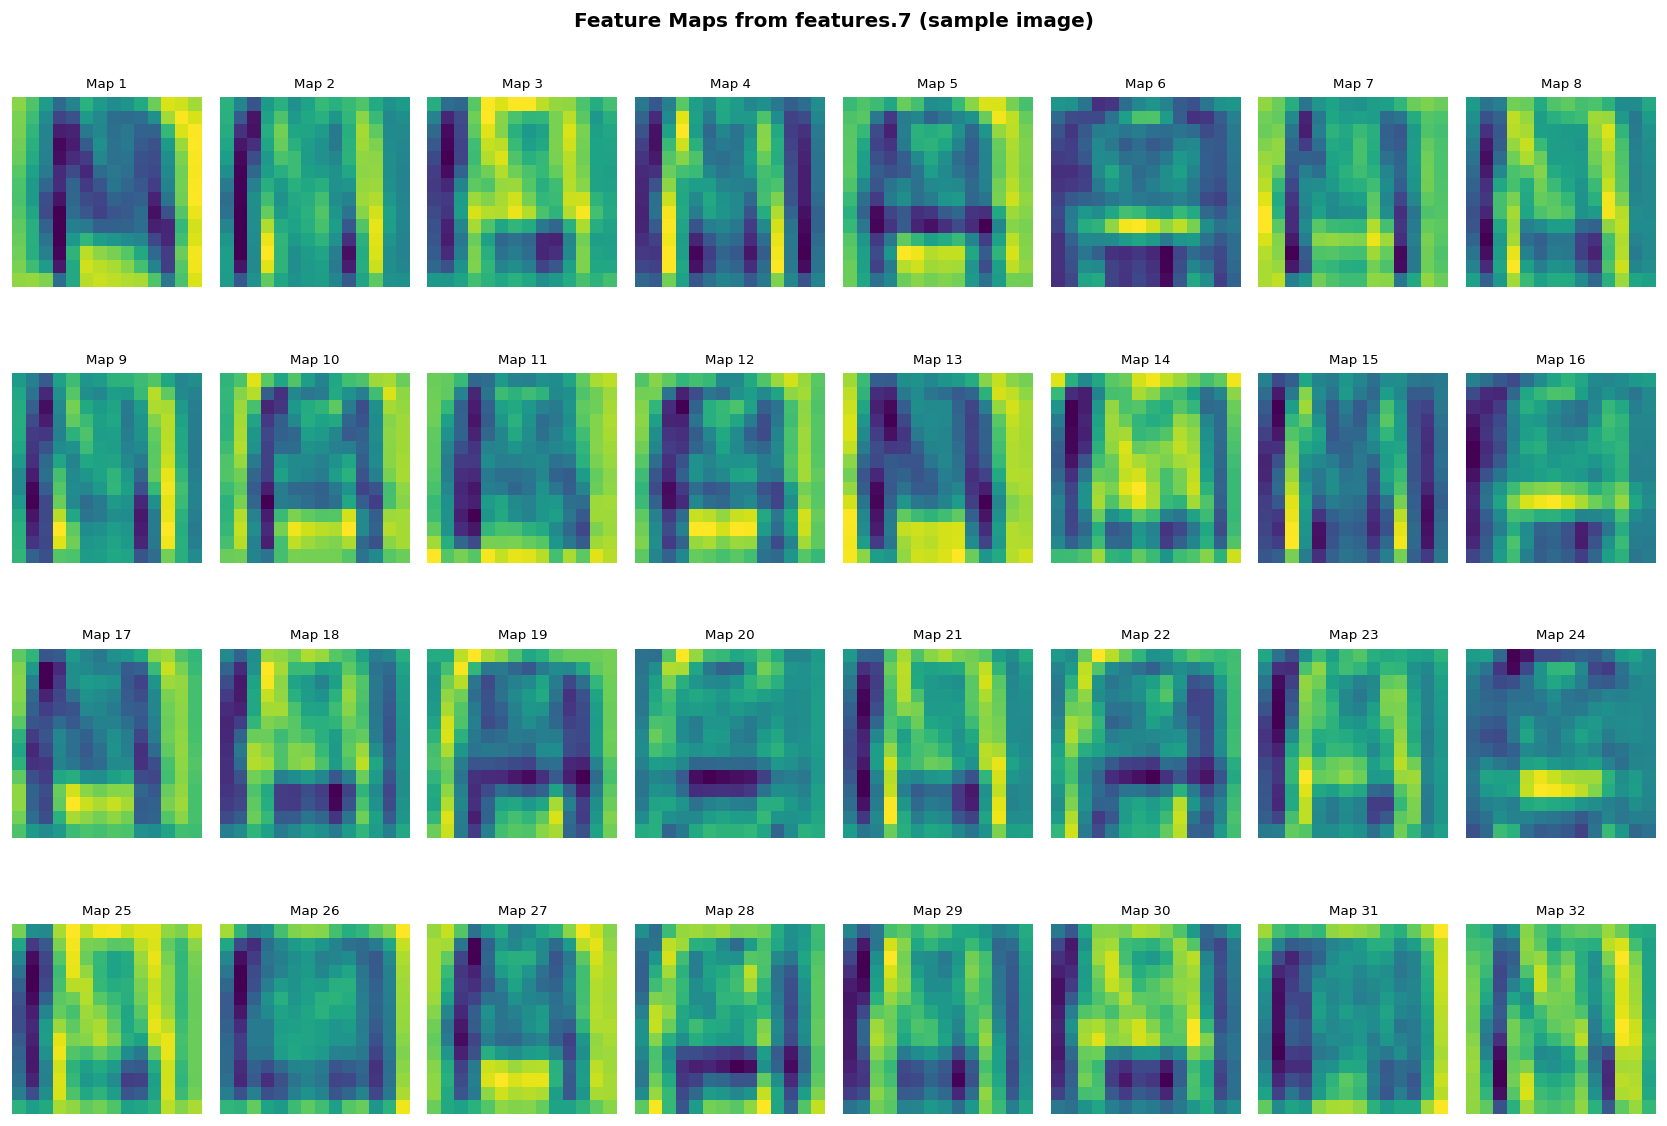

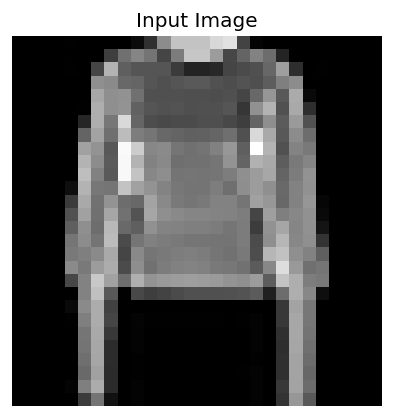

In [23]:
# ============================================================================
# Feature Map & Filter Visualization (Fixed)
# ============================================================================

def visualize_filters(model, layer_name, figsize=(12, 8)):
    """Visualize filters/kernels from a convolutional layer."""
    for name, module in model.named_modules():
        if name == layer_name:
            filters = module.weight.data.cpu().numpy()
            # filters shape: (out_channels, in_channels, height, width)
            n_filters = min(32, filters.shape[0])  # Show up to 32 filters
            n_cols = 8
            n_rows = (n_filters + n_cols - 1) // n_cols
            
            fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize)
            if n_rows == 1:
                axes = axes.reshape(1, -1)
            axes = axes.flatten()
            fig.suptitle(f'Filters from {layer_name} ({n_filters} shown)', 
                         fontsize=12, fontweight='bold')
            
            for i in range(n_filters):
                # Handle different input channel dimensions
                if filters.shape[1] == 1:  # Grayscale input
                    filt = filters[i, 0]  # Shape: (height, width)
                    axes[i].imshow(filt, cmap='gray')
                elif filters.shape[1] == 3:  # RGB input
                    # For RGB, we need to normalize each channel and combine
                    filt = filters[i].transpose(1, 2, 0)  # Shape: (height, width, channels)
                    # Normalize each channel independently
                    filt_norm = np.zeros_like(filt)
                    for c in range(3):
                        channel = filt[:, :, c]
                        if channel.max() - channel.min() > 0:
                            filt_norm[:, :, c] = (channel - channel.min()) / (channel.max() - channel.min())
                        else:
                            filt_norm[:, :, c] = channel
                    axes[i].imshow(filt_norm)
                else:
                    # For multiple input channels, show the first few or average
                    n_in_channels = min(3, filters.shape[1])  # Show up to 3 channels
                    if n_in_channels == 1:
                        filt = filters[i, 0]
                        axes[i].imshow(filt, cmap='gray')
                    else:
                        # Create an RGB composite from first 3 input channels
                        rgb_filt = np.zeros((filters.shape[2], filters.shape[3], 3))
                        for c in range(n_in_channels):
                            channel = filters[i, c]
                            if channel.max() - channel.min() > 0:
                                rgb_filt[:, :, c] = (channel - channel.min()) / (channel.max() - channel.min())
                            else:
                                rgb_filt[:, :, c] = channel
                        axes[i].imshow(rgb_filt)
                
                axes[i].axis('off')
                axes[i].set_title(f'Filter {i+1}', fontsize=8)
            
            # Turn off unused subplots
            for j in range(i+1, len(axes)):
                axes[j].axis('off')
            
            plt.tight_layout()
            plt.show()
            return
    print(f"Layer '{layer_name}' not found")

def visualize_feature_maps(model, image, layer_name, figsize=(14, 10)):
    """Visualize feature maps from a specific layer for a given input image."""
    # Register hook to get activations
    activations = []
    
    def hook_fn(module, input, output):
        activations.append(output.detach())
    
    # Find and hook the target layer
    handle = None
    for name, module in model.named_modules():
        if name == layer_name:
            handle = module.register_forward_hook(hook_fn)
            break
    else:
        print(f"Layer '{layer_name}' not found")
        return
    
    # Ensure image is on the correct device and has batch dimension
    if isinstance(image, np.ndarray):
        image = torch.from_numpy(image)
    
    # Add batch dimension if missing
    if image.dim() == 3:
        image = image.unsqueeze(0)
    
    # Forward pass
    model.eval()
    with torch.no_grad():
        # Move to device
        image = image.to(next(model.parameters()).device)
        _ = model(image)
    
    # Remove hook
    if handle is not None:
        handle.remove()
    
    # Get activations
    if not activations:
        print(f"No activations captured for layer '{layer_name}'")
        return
    
    act = activations[0].cpu().squeeze(0).numpy()
    
    # Handle different activation shapes
    if act.ndim == 2:
        # Fully connected layer output
        plt.figure(figsize=(10, 6))
        plt.bar(range(len(act)), act)
        plt.title(f'Activation values from {layer_name}')
        plt.xlabel('Neuron index')
        plt.ylabel('Activation value')
        plt.show()
        return
    
    # For convolutional layers
    n_maps = min(32, act.shape[0])
    n_cols = 8
    n_rows = (n_maps + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize)
    if n_rows == 1:
        axes = axes.reshape(1, -1)
    axes = axes.flatten()
    fig.suptitle(f'Feature Maps from {layer_name} (sample image)', 
                 fontsize=12, fontweight='bold')
    
    for i in range(n_maps):
        feature_map = act[i]
        # Normalize for better visualization
        if feature_map.max() - feature_map.min() > 0:
            feature_map_norm = (feature_map - feature_map.min()) / (feature_map.max() - feature_map.min())
        else:
            feature_map_norm = feature_map
        
        axes[i].imshow(feature_map_norm, cmap='viridis')
        axes[i].axis('off')
        axes[i].set_title(f'Map {i+1}', fontsize=8)
    
    # Turn off unused subplots
    for j in range(i+1, len(axes)):
        axes[j].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    # Also show the input image for reference
    plt.figure(figsize=(4, 4))
    # Handle grayscale vs RGB input
    input_img = image.cpu().squeeze().numpy()
    if input_img.ndim == 3 and input_img.shape[0] == 3:
        # RGB image
        input_img = input_img.transpose(1, 2, 0)
        # Denormalize if needed (assuming normalization was applied)
        # This is a placeholder - adjust based on your preprocessing
        input_img = (input_img - input_img.min()) / (input_img.max() - input_img.min())
        plt.imshow(input_img)
    else:
        # Grayscale image
        plt.imshow(input_img, cmap='gray')
    
    plt.title('Input Image')
    plt.axis('off')
    plt.show()

# Visualize filters from trained model (Rule 3)
print("\n" + "="*60)
print("  CNN Feature Map & Filter Visualization")
print("="*60)

# Use the best model (Rule 3)
model_to_visualize = model_r3  # or model_r2 if you prefer

# Get a sample image (choose one from test set)
sample_img, sample_label = next(iter(test_loader_f))
sample_img = sample_img[0].cpu()
print(f"Sample image class: {CLASS_NAMES[sample_label[0].item()]}")

# Visualize filters from conv layers
print("\n--- Conv2d Layer Filters ---")
for name, module in model_to_visualize.named_modules():
    if isinstance(module, nn.Conv2d):
        visualize_filters(model_to_visualize, name, figsize=(12, 8))

# Visualize feature maps for sample image
print("\n--- Feature Maps at Different Layers ---")
layer_names = [name for name, _ in model_to_visualize.named_modules() 
               if isinstance(_, nn.Conv2d)]

# Also include activation layers if you want to see feature maps after ReLU
for layer_name in layer_names:
    visualize_feature_maps(model_to_visualize, sample_img, layer_name, figsize=(14, 10))

### Rule 4 — Full Sample (7k) + Regularization
Batch Normalization + L2 Weight Decay + Data Augmentation.

In [22]:
class RegularizedCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1,  32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32), nn.ReLU(),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64), nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 256),
            nn.BatchNorm1d(256), nn.ReLU(),
            nn.Linear(256, 128),
            nn.BatchNorm1d(128), nn.ReLU(),
            nn.Linear(128, 10)
        )
    def forward(self, x): return self.classifier(self.features(x))

print(RegularizedCNN())
print(f'Total parameters: {sum(p.numel() for p in RegularizedCNN().parameters()):,}')


RegularizedCNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (9): ReLU()
    (10): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (12): ReLU()
    (13): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_d

In [23]:
class AugmentedDataset(Dataset):
    def __init__(self, X, y, augment=False):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)
        self.augment = augment
        self.transform = transforms.Compose([
            transforms.RandomHorizontalFlip(),
            transforms.RandomAffine(degrees=10, translate=(0.1, 0.1)),
        ])
    def __len__(self): return len(self.y)
    def __getitem__(self, idx):
        x = self.X[idx]
        if self.augment: x = self.transform(x)
        return x, self.y[idx]

def make_aug_loaders(X, y, batch_size=64):
    X_r = X.reshape(-1, 1, 28, 28).astype(np.float32) / 255.0
    X_tr, X_tmp, y_tr, y_tmp = train_test_split(X_r, y, test_size=0.20, stratify=y, random_state=42)
    X_v, X_te, y_v, y_te = train_test_split(X_tmp, y_tmp, test_size=0.50, stratify=y_tmp, random_state=42)
    trl = DataLoader(AugmentedDataset(X_tr, y_tr, augment=True), batch_size=batch_size, shuffle=True)
    vl  = DataLoader(AugmentedDataset(X_v,  y_v),  batch_size=batch_size)
    tel = DataLoader(AugmentedDataset(X_te, y_te), batch_size=batch_size)
    print(f'Train: {len(y_tr):,} | Val: {len(y_v):,} | Test: {len(y_te):,}')
    return trl, vl, tel, X_te, y_te

train_loader_aug, val_loader_aug, test_loader_aug, X_te_aug, y_te_aug = make_aug_loaders(X_sample, y_sample)


Train: 4,796 | Val: 599 | Test: 600


  RULE 4 — Full Data + BatchNorm + L2 + Augmentation
 Epoch   Train Loss   Val Loss   Train Acc   Val Acc
-------------------------------------------------------
     1       0.9628     0.5618      67.83%    79.80%
     2       0.6295     0.5643      77.61%    78.63%
     3       0.5484     0.4624      79.88%    83.47%
     4       0.5052     0.4626      81.38%    83.31%
     5       0.4765     0.3760      82.19%    87.65%
     6       0.4438     0.4074      83.26%    85.14%
     7       0.4247     0.3463      84.49%    86.48%
     8       0.4000     0.3172      85.74%    88.81%
     9       0.3947     0.3688      85.40%    86.14%
    10       0.3819     0.3165      85.57%    87.81%
    11       0.3516     0.3461      86.93%    88.81%
    12       0.3449     0.3921      87.01%    87.65%
    13       0.3321     0.4649      88.24%    84.47%
    14       0.3287     0.3113      87.84%    88.98%
    15       0.3121     0.4013      88.47%    85.31%
    16       0.3184     0.2753      88.20% 

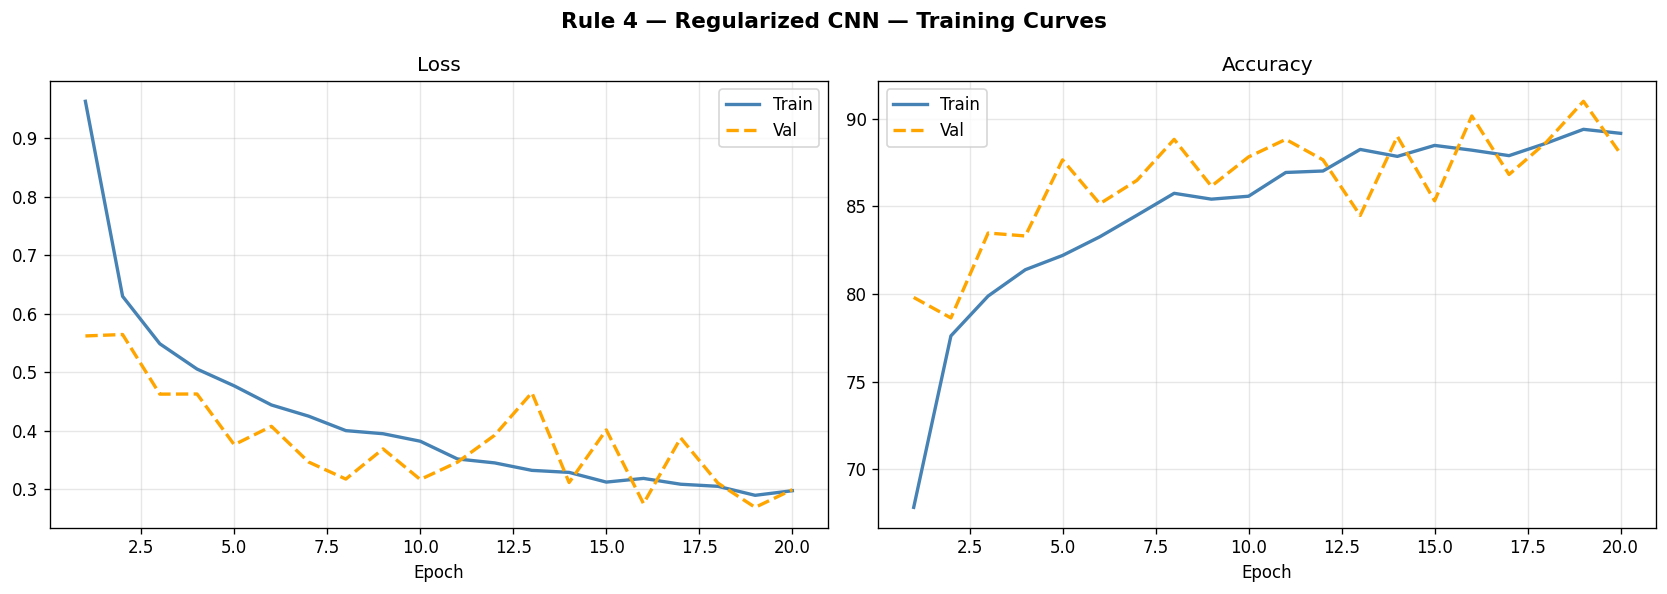


VALIDATION — Accuracy: 90.98%
              precision    recall  f1-score   support

 T-shirt/top       0.95      0.88      0.91        60
     Trouser       0.98      0.97      0.97        60
    Pullover       0.83      0.85      0.84        59
       Dress       0.95      0.92      0.93        60
        Coat       0.89      0.83      0.86        60
      Sandal       0.98      0.98      0.98        60
       Shirt       0.67      0.80      0.73        60
     Sneaker       0.95      0.95      0.95        60
         Bag       1.00      0.95      0.97        60
  Ankle boot       0.95      0.97      0.96        60

    accuracy                           0.91       599
   macro avg       0.92      0.91      0.91       599
weighted avg       0.92      0.91      0.91       599

TEST — Accuracy: 88.00%
              precision    recall  f1-score   support

 T-shirt/top       0.87      0.75      0.80        60
     Trouser       1.00      1.00      1.00        60
    Pullover       0.88

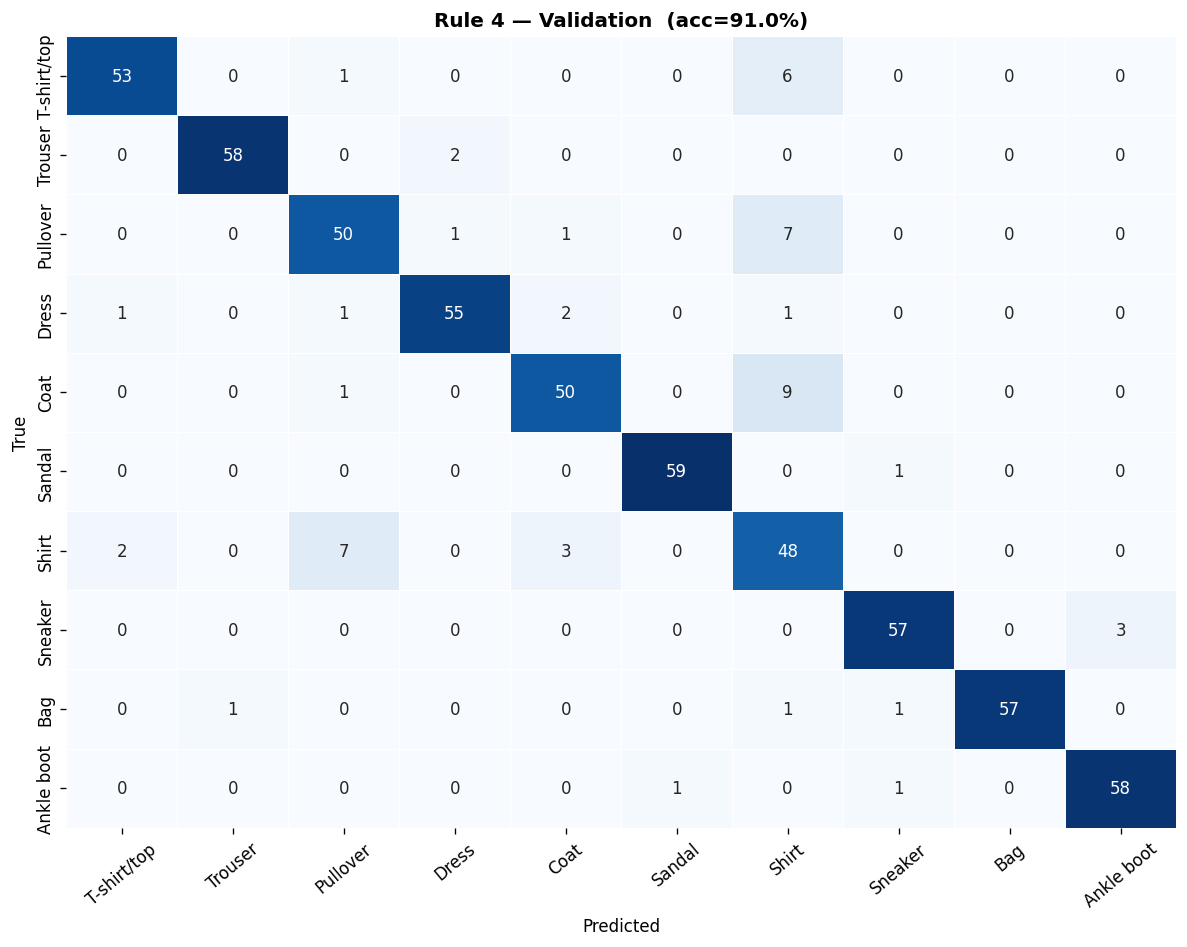

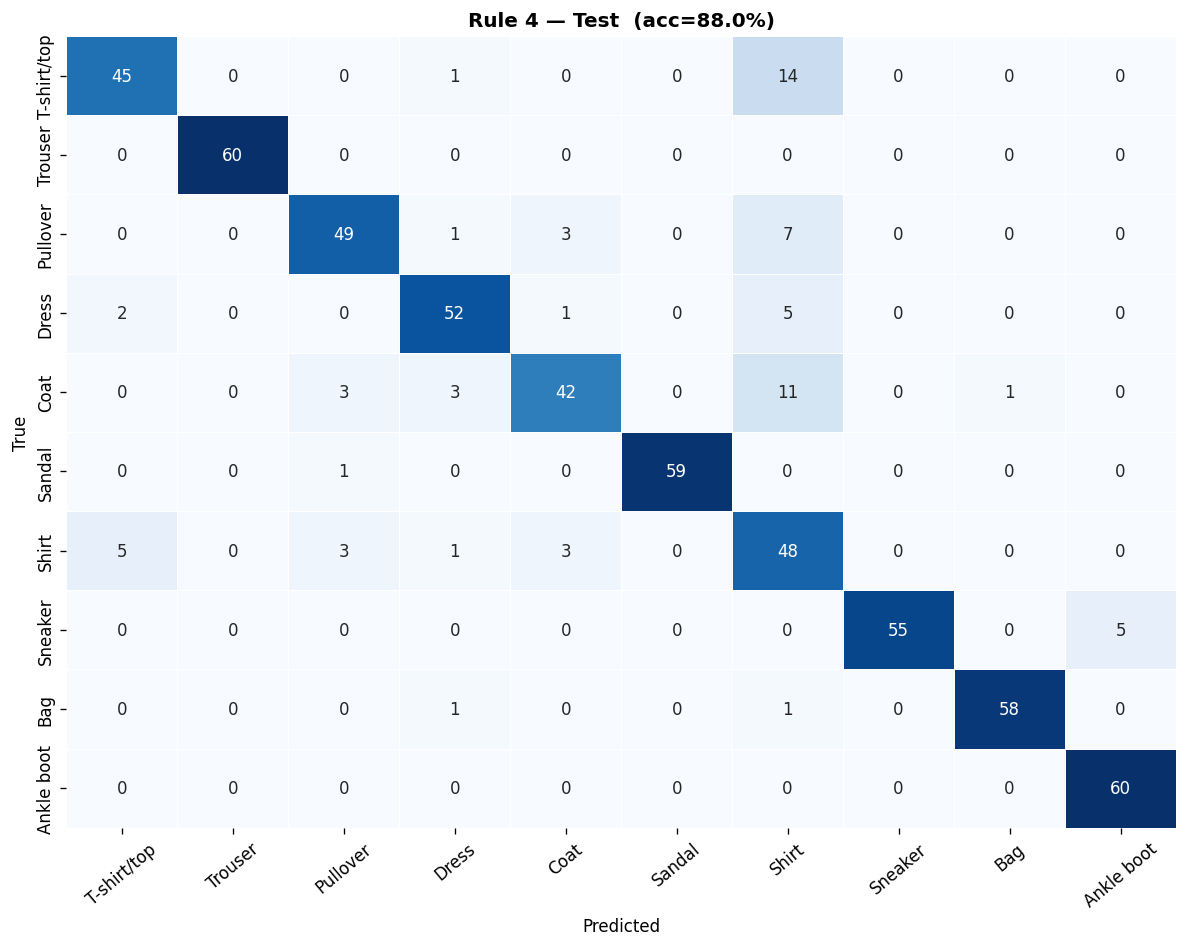

In [24]:
print('=' * 55)
print('  RULE 4 — Full Data + BatchNorm + L2 + Augmentation')
print('=' * 55)

torch.manual_seed(42)
model_r4 = RegularizedCNN().to(device)
losses_r4 = train_model(model_r4, train_loader_aug, val_loader_aug,
                         epochs=20, lr=0.001, weight_decay=1e-4)
plot_curves(*losses_r4, title='Rule 4 — Regularized CNN')
val_acc_r4, test_acc_r4 = full_evaluation(model_r4, val_loader_aug, test_loader_aug, 'Rule 4')


### CNN Golden Rules — Summary

Model                                         Val Acc   Test Acc
Rule 1 — Small Set (2k),  Naive CNN            86.50%     84.00%
Rule 2 — Sample (7k),     Naive CNN            87.81%     87.50%
Rule 3 — Sample (7k),     Deeper CNN           88.48%     87.50%
Rule 4 — Sample (7k),  Regularized             90.98%     88.00%


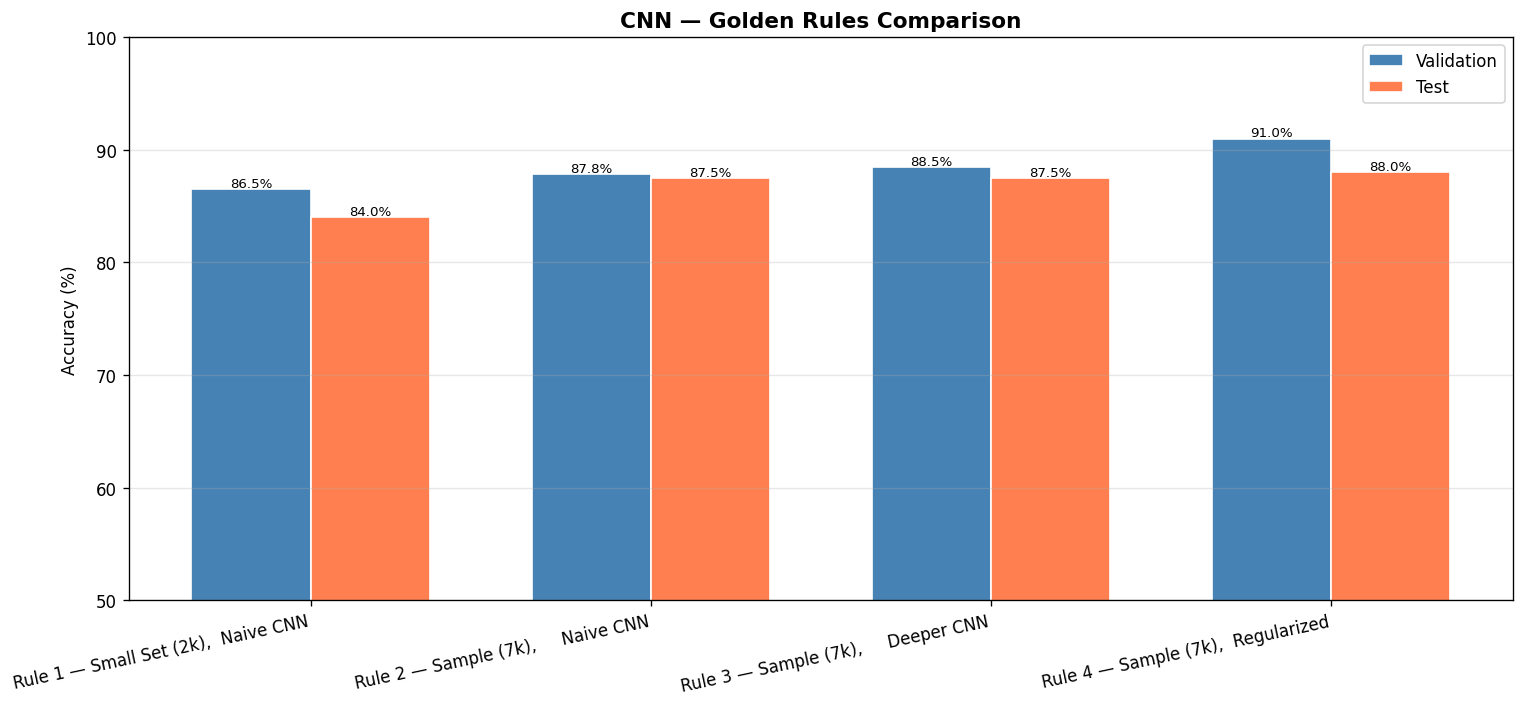

In [25]:
results = {
    'Rule 1 — Small Set (2k),  Naive CNN'   : (val_acc_r1, test_acc_r1),
    'Rule 2 — Sample (7k),     Naive CNN'   : (val_acc_r2, test_acc_r2),
    'Rule 3 — Sample (7k),     Deeper CNN'  : (val_acc_r3, test_acc_r3),
    'Rule 4 — Sample (7k),  Regularized'    : (val_acc_r4, test_acc_r4),
}

print(f"{'Model':<42} {'Val Acc':>10} {'Test Acc':>10}")
print('=' * 64)
for name, (va, ta) in results.items():
    print(f'{name:<42} {va*100:>9.2f}% {ta*100:>9.2f}%')

labels = list(results.keys())
va_all = [v[0]*100 for v in results.values()]
ta_all = [v[1]*100 for v in results.values()]
x = np.arange(4); w = 0.35
fig, ax = plt.subplots(figsize=(13, 6))
b1 = ax.bar(x-w/2, va_all, w, label='Validation', color='steelblue', edgecolor='white')
b2 = ax.bar(x+w/2, ta_all, w, label='Test',       color='coral',     edgecolor='white')
ax.set_xticks(x); ax.set_xticklabels(labels, rotation=12, ha='right')
ax.set_ylim(50, 100); ax.set_ylabel('Accuracy (%)')
ax.set_title('CNN — Golden Rules Comparison', fontsize=13, fontweight='bold')
ax.legend(); ax.grid(axis='y', alpha=0.3)
for bar in [*b1, *b2]:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.2,
            f'{bar.get_height():.1f}%', ha='center', fontsize=8)
plt.tight_layout(); plt.show()


## CNN Golden Rules — Insights

The results show a clear progression in how the model improves step by step, with each rule building on the previous one.

At the beginning, using only **2k samples**, the basic CNN already reached **84% test accuracy**, which is honestly a very good starting point. It shows that the architecture itself works and that the problem is learnable. This is exactly what the first rule aims to check — making sure the baseline model is reasonable before making any changes.

When the dataset was increased to **7k samples** (Rule 2), the **test accuracy went up to 87.5%** without changing the architecture at all. That improvement came simply from giving the model more data to learn from. It’s a good reminder that increasing the dataset can often improve performance more than modifying the model, especially in the early stages.

In Rule 3, the model was made deeper by adding more convolutional layers. This slightly increased the **validation accuracy to 88.48%**, but the **test accuracy stayed at 87.5%**. This suggests that just adding more layers doesn’t necessarily improve generalization, especially when the available data is limited.

Rule 4 introduced **Batch Normalization, L2 regularization, and data augmentation**, and this is where the biggest improvement happened. The **validation accuracy increased to 90.98%**, and the **test accuracy reached 88%**. These techniques help the model generalize better. Data augmentation, for example, exposes the model to slightly different versions of the same images, which helps it become more robust.


---
## 6. Transfer Learning — ResNet18

We use a pretrained ResNet18 (trained on ImageNet). Fashion MNIST images are resized to 224×224 and converted to 3 channels to match ResNet18's expected input. Three fine-tuning scenarios are compared:
- **6-A** — Freeze all layers, train only the final FC classifier
- **6-B** — Freeze early layers, fine-tune `layer4` (high-level features) + FC
- **6-C** — Fine-tune the entire model end-to-end

In [26]:
from torchvision import models, transforms
from torch.utils.data import Dataset

# ── Dataset with resize + 3-channel conversion ───────────
class FashionTLDataset(Dataset):
    def __init__(self, X, y, augment=False):
        self.X = X.reshape(-1, 28, 28).astype(np.float32) / 255.0
        self.y = torch.tensor(y, dtype=torch.long)
        base = transforms.Compose([
            transforms.ToPILImage(),
            transforms.Resize((224, 224)),
            transforms.Grayscale(num_output_channels=3),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                  std=[0.229, 0.224, 0.225]),
        ])
        aug = transforms.Compose([
            transforms.ToPILImage(),
            transforms.Resize((224, 224)),
            transforms.Grayscale(num_output_channels=3),
            transforms.RandomHorizontalFlip(),
            transforms.RandomAffine(degrees=10, translate=(0.1, 0.1)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                  std=[0.229, 0.224, 0.225]),
        ])
        self.transform = aug if augment else base

    def __len__(self): return len(self.y)
    def __getitem__(self, idx):
        img = (self.X[idx] * 255).astype(np.uint8)
        return self.transform(img), self.y[idx]


def make_tl_loaders(X, y, batch_size=64):
    X_tr, X_tmp, y_tr, y_tmp = train_test_split(X, y, test_size=0.20, stratify=y, random_state=42)
    X_v, X_te, y_v, y_te = train_test_split(X_tmp, y_tmp, test_size=0.50, stratify=y_tmp, random_state=42)
    trl = DataLoader(FashionTLDataset(X_tr, y_tr, augment=True), batch_size=batch_size, shuffle=True, num_workers=0)
    vl  = DataLoader(FashionTLDataset(X_v,  y_v),  batch_size=batch_size, num_workers=0)
    tel = DataLoader(FashionTLDataset(X_te, y_te), batch_size=batch_size, num_workers=0)
    print(f'Train: {len(y_tr):,} | Val: {len(y_v):,} | Test: {len(y_te):,}')
    return trl, vl, tel

tl_train, tl_val, tl_test = make_tl_loaders(X_sample, y_sample)


Train: 4,796 | Val: 599 | Test: 600


In [27]:
# ── Generic TL training + evaluation helpers ─────────────
def train_tl(model, train_loader, val_loader, epochs=15, lr=1e-3, label=''):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=lr)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, factor=0.5)
    train_losses, val_losses, train_accs, val_accs = [], [], [], []
    best_val, patience_cnt, best_state = np.inf, 0, None

    print(f'\n{label}')
    print(f"{'Epoch':>6} {'Train Loss':>12} {'Val Loss':>10} {'Train Acc':>11} {'Val Acc':>9}")
    print('-' * 55)

    for epoch in range(1, epochs+1):
        model.train(); tl, correct, total = 0, 0, 0
        for Xb, yb in train_loader:
            Xb, yb = Xb.to(device), yb.to(device)
            optimizer.zero_grad(); out = model(Xb); loss = criterion(out, yb)
            loss.backward(); optimizer.step()
            tl += loss.item()*len(yb); correct += (out.argmax(1)==yb).sum().item(); total += len(yb)
        tl /= total; ta = correct/total

        model.eval(); vl, correct, total = 0, 0, 0
        with torch.no_grad():
            for Xb, yb in val_loader:
                Xb, yb = Xb.to(device), yb.to(device)
                out = model(Xb); loss = criterion(out, yb)
                vl += loss.item()*len(yb); correct += (out.argmax(1)==yb).sum().item(); total += len(yb)
        vl /= total; va = correct/total

        train_losses.append(tl); val_losses.append(vl)
        train_accs.append(ta);   val_accs.append(va)
        scheduler.step(vl)
        print(f'{epoch:>6} {tl:>12.4f} {vl:>10.4f} {ta*100:>10.2f}% {va*100:>8.2f}%')

        if vl < best_val - 1e-4:
            best_val = vl; best_state = {k: v.clone() for k, v in model.state_dict().items()}; patience_cnt = 0
        else:
            patience_cnt += 1
            if patience_cnt >= 7: print(f'  Early stopping at epoch {epoch}'); break

    model.load_state_dict(best_state)
    return train_losses, val_losses, train_accs, val_accs


def evaluate_tl(model, loader):
    model.eval(); preds, labels = [], []
    with torch.no_grad():
        for Xb, yb in loader:
            preds.extend(model(Xb.to(device)).argmax(1).cpu().numpy())
            labels.extend(yb.numpy())
    return np.array(labels), np.array(preds)


def tl_report(model, val_loader, test_loader, title):
    yv, pv = evaluate_tl(model, val_loader)
    yt, pt = evaluate_tl(model, test_loader)
    va = accuracy_score(yv, pv); ta = accuracy_score(yt, pt)
    print(f'\nVALIDATION — {title}  Acc: {va*100:.2f}%')
    print(classification_report(yv, pv, target_names=CLASS_NAMES))
    print(f'TEST — {title}  Acc: {ta*100:.2f}%')
    print(classification_report(yt, pt, target_names=CLASS_NAMES))
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    for ax, y_true, y_pred, t in [
        (axes[0], yv, pv, f'{title} Val  ({va*100:.1f}%)'),
        (axes[1], yt, pt, f'{title} Test ({ta*100:.1f}%)')
    ]:
        cm = confusion_matrix(y_true, y_pred)
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                    xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, linewidths=0.4, cbar=False)
        ax.set_title(t, fontsize=11, fontweight='bold')
        ax.set_xlabel('Predicted'); ax.set_ylabel('True')
        ax.tick_params(axis='x', rotation=40)
    plt.tight_layout(); plt.show()
    return va, ta


### 6-A — Freeze All, Train FC Only
All ResNet18 weights frozen. Only the new 10-class FC head is trained. Fastest to run, tests raw transferability of ImageNet features.

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\hazem/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [02:50<00:00, 274kB/s]  


Trainable: 5,130 / 11,181,642 (0.0%)

6-A: Frozen Backbone — FC Only
 Epoch   Train Loss   Val Loss   Train Acc   Val Acc
-------------------------------------------------------
     1       1.5394     1.1672      51.36%    70.95%
     2       0.9572     0.8558      71.43%    76.29%
     3       0.8083     0.7440      73.96%    78.63%
     4       0.7551     0.7034      75.33%    75.63%
     5       0.7025     0.6443      75.98%    80.47%
     6       0.6607     0.6318      77.73%    79.80%
     7       0.6442     0.6163      78.36%    78.96%
     8       0.6303     0.6123      78.02%    77.63%
     9       0.6175     0.6343      79.13%    76.29%
    10       0.6065     0.5880      78.32%    78.96%
    11       0.5966     0.5994      78.86%    78.96%
    12       0.5930     0.5683      79.44%    79.97%
    13       0.5646     0.5990      80.38%    77.46%
    14       0.5679     0.5584      79.96%    81.14%
    15       0.5690     0.5607      79.30%    80.13%


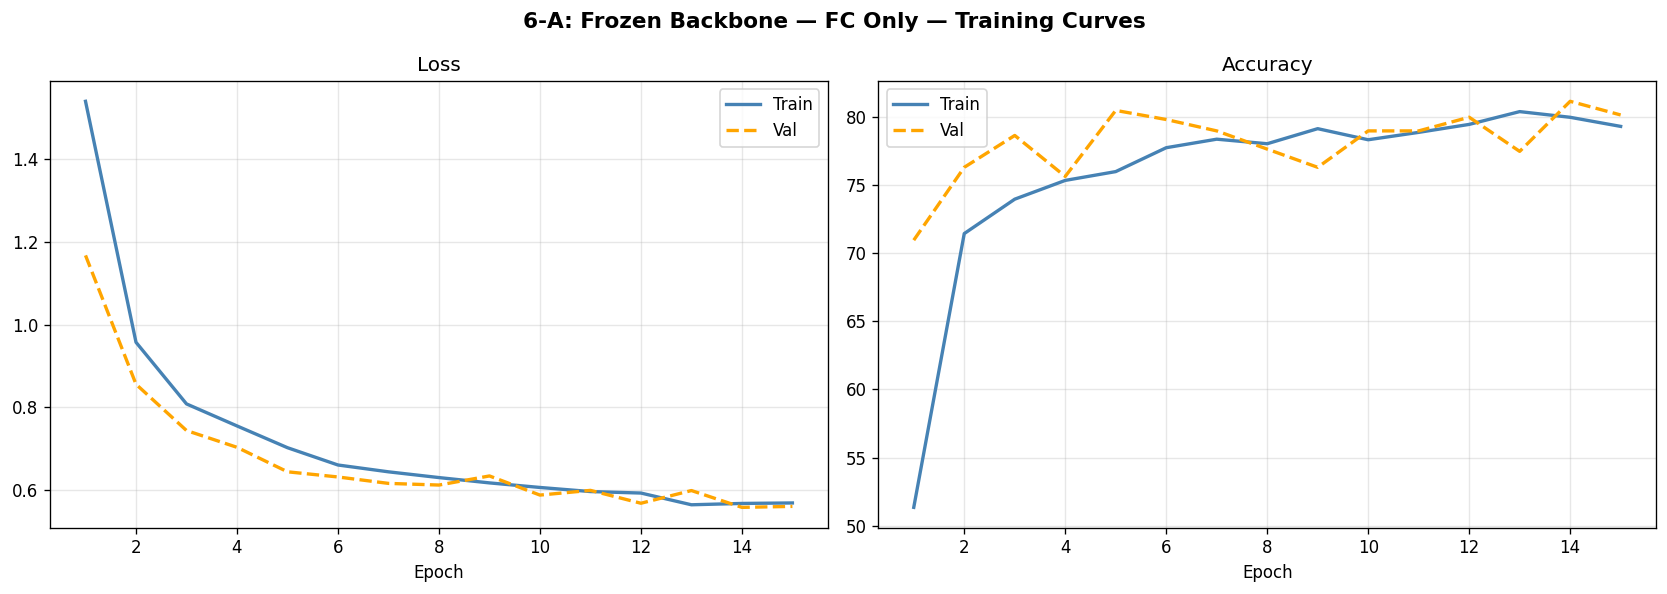


VALIDATION — 6-A FC Only  Acc: 81.14%
              precision    recall  f1-score   support

 T-shirt/top       0.63      0.87      0.73        60
     Trouser       0.94      0.97      0.95        60
    Pullover       0.79      0.83      0.81        59
       Dress       0.78      0.82      0.80        60
        Coat       0.74      0.67      0.70        60
      Sandal       0.89      0.93      0.91        60
       Shirt       0.65      0.43      0.52        60
     Sneaker       0.85      0.88      0.87        60
         Bag       0.96      0.80      0.87        60
  Ankle boot       0.90      0.92      0.91        60

    accuracy                           0.81       599
   macro avg       0.81      0.81      0.81       599
weighted avg       0.81      0.81      0.81       599

TEST — 6-A FC Only  Acc: 78.00%
              precision    recall  f1-score   support

 T-shirt/top       0.63      0.82      0.71        60
     Trouser       0.95      1.00      0.98        60
    Pul

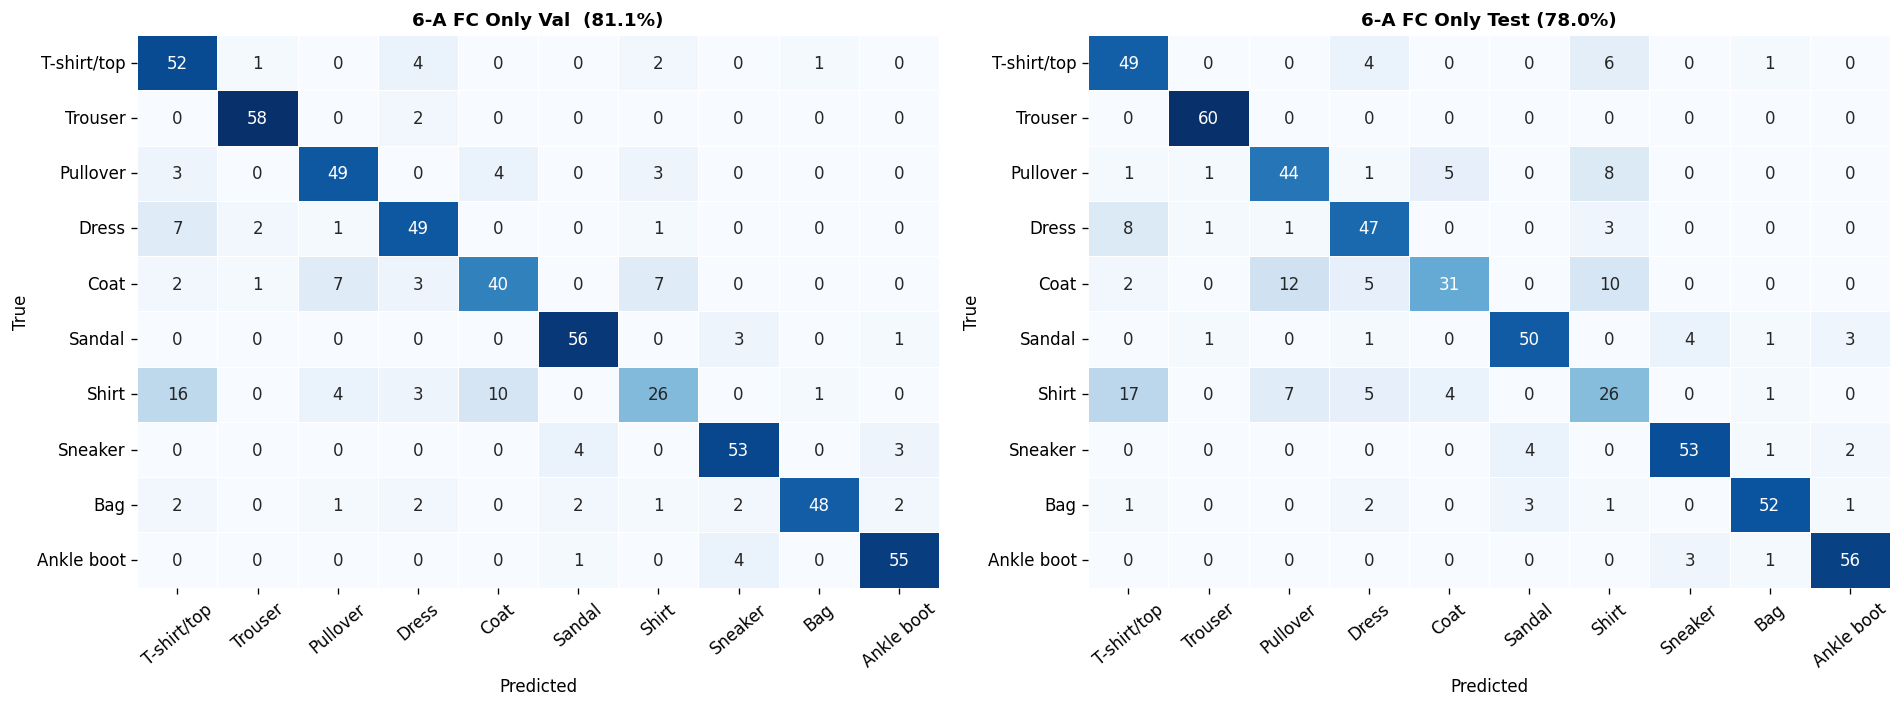

In [28]:
def build_resnet_3A():
    model = models.resnet18(weights='IMAGENET1K_V1')
    for param in model.parameters():
        param.requires_grad = False       # freeze everything
    model.fc = nn.Linear(model.fc.in_features, 10)   # new head
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total     = sum(p.numel() for p in model.parameters())
    print(f'Trainable: {trainable:,} / {total:,} ({trainable/total*100:.1f}%)')
    return model.to(device)

torch.manual_seed(42)
model_3a = build_resnet_3A()
losses_3a = train_tl(model_3a, tl_train, tl_val, epochs=15, lr=1e-3,
                     label='6-A: Frozen Backbone — FC Only')
plot_curves(*losses_3a, title='6-A: Frozen Backbone — FC Only')
val_acc_3a, test_acc_3a = tl_report(model_3a, tl_val, tl_test, '6-A FC Only')


### 6-B — Fine-tune Final Layers (layer4 + FC)
Freeze up to `layer3`, unfreeze `layer4` (high-level feature extractor) and the FC head. Balances speed and adaptability.

Trainable: 8,398,858 / 11,181,642 (75.1%)

6-B: Fine-tune layer4 + FC
 Epoch   Train Loss   Val Loss   Train Acc   Val Acc
-------------------------------------------------------
     1       0.8327     0.5212      72.21%    80.30%
     2       0.4326     0.3780      85.01%    88.15%
     3       0.3523     0.3572      87.84%    86.64%
     4       0.3149     0.3288      88.84%    88.31%
     5       0.2766     0.3275      90.24%    88.15%
     6       0.2372     0.3114      91.43%    89.98%
     7       0.2255     0.3844      92.20%    86.81%
     8       0.2064     0.3379      92.51%    88.31%
     9       0.1750     0.3382      93.56%    89.48%
    10       0.1584     0.3709      94.31%    88.81%
    11       0.1339     0.3190      95.64%    88.98%
    12       0.1122     0.3150      96.41%    90.65%
    13       0.0962     0.3187      97.33%    89.32%
  Early stopping at epoch 13


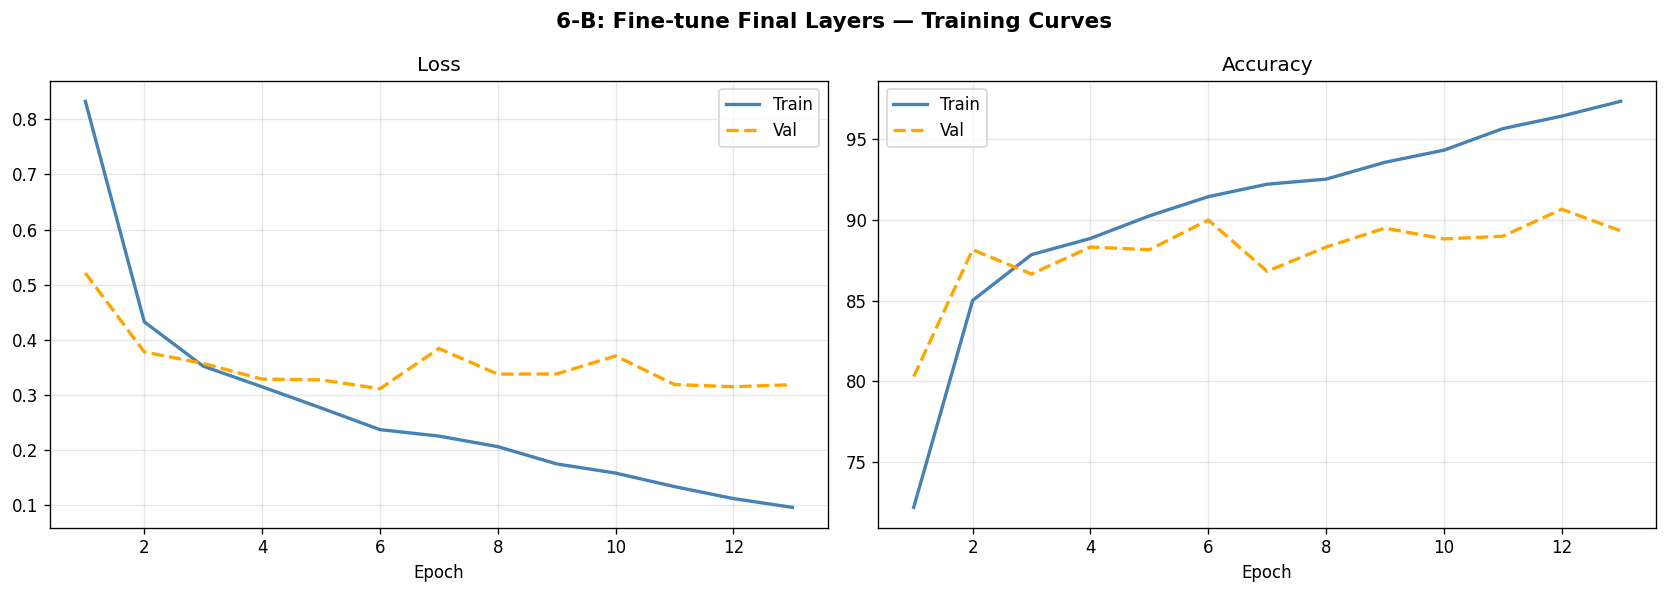


VALIDATION — 6-B Fine-tune Final  Acc: 89.98%
              precision    recall  f1-score   support

 T-shirt/top       0.82      0.93      0.88        60
     Trouser       1.00      0.98      0.99        60
    Pullover       0.80      0.93      0.86        59
       Dress       0.96      0.83      0.89        60
        Coat       0.79      0.93      0.85        60
      Sandal       0.95      0.97      0.96        60
       Shirt       0.81      0.58      0.68        60
     Sneaker       0.95      0.92      0.93        60
         Bag       0.98      0.93      0.96        60
  Ankle boot       0.97      0.98      0.98        60

    accuracy                           0.90       599
   macro avg       0.90      0.90      0.90       599
weighted avg       0.90      0.90      0.90       599

TEST — 6-B Fine-tune Final  Acc: 88.67%
              precision    recall  f1-score   support

 T-shirt/top       0.76      0.85      0.80        60
     Trouser       0.97      1.00      0.98  

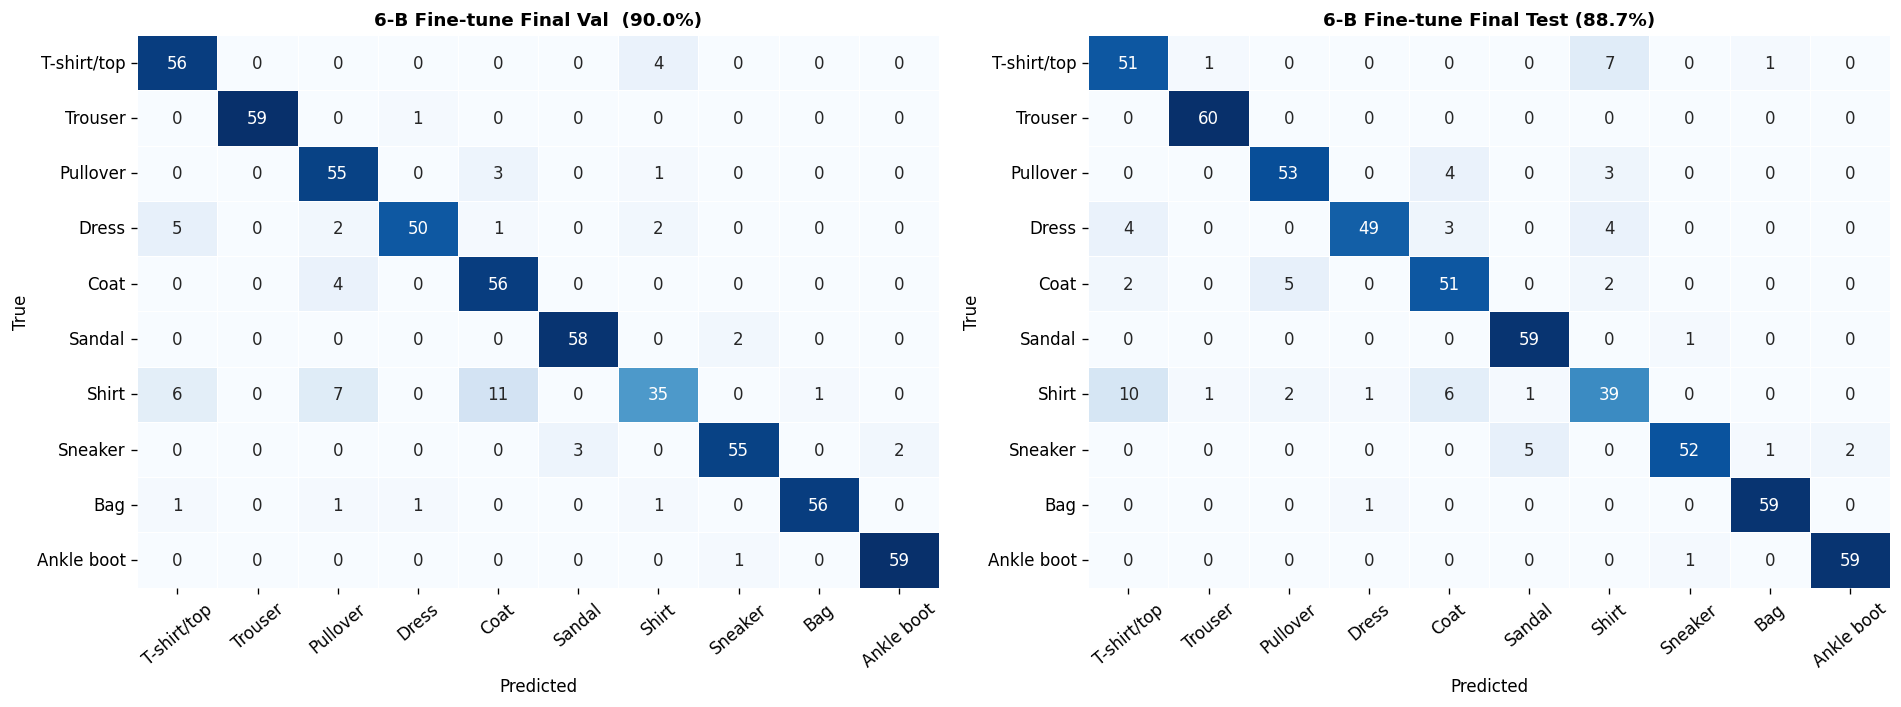

In [29]:
def build_resnet_3B():
    model = models.resnet18(weights='IMAGENET1K_V1')
    for param in model.parameters():
        param.requires_grad = False       # freeze all first
    for param in model.layer4.parameters():
        param.requires_grad = True        # unfreeze layer4
    model.fc = nn.Linear(model.fc.in_features, 10)
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total     = sum(p.numel() for p in model.parameters())
    print(f'Trainable: {trainable:,} / {total:,} ({trainable/total*100:.1f}%)')
    return model.to(device)

torch.manual_seed(42)
model_3b = build_resnet_3B()
losses_3b = train_tl(model_3b, tl_train, tl_val, epochs=15, lr=1e-4,
                     label='6-B: Fine-tune layer4 + FC')
plot_curves(*losses_3b, title='6-B: Fine-tune Final Layers')
val_acc_3b, test_acc_3b = tl_report(model_3b, tl_val, tl_test, '6-B Fine-tune Final')


### 6-C — Full Fine-tuning
All layers unfrozen, entire ResNet18 trained end-to-end. Low LR to preserve pretrained weights.

In [ ]:
def build_resnet_3C():
    model = models.resnet18(weights='IMAGENET1K_V1')
    for param in model.parameters():
        param.requires_grad = True       
    model.fc = nn.Linear(model.fc.in_features, 10)
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total     = sum(p.numel() for p in model.parameters())
    print(f'Trainable: {trainable:,} / {total:,} ({trainable/total*100:.1f}%)')
    return model.to(device)

torch.manual_seed(42)
model_3c = build_resnet_3C()
losses_3c = train_tl(model_3c, tl_train, tl_val, epochs=15, lr=1e-5,
                     label='6-C: Full Fine-tuning')
plot_curves(*losses_3c, title='6-C: Full Fine-tuning')
val_acc_3c, test_acc_3c = tl_report(model_3c, tl_val, tl_test, '6-C Full Fine-tune')


Trainable: 11,181,642 / 11,181,642 (100.0%)

6-C: Full Fine-tuning
 Epoch   Train Loss   Val Loss   Train Acc   Val Acc
-------------------------------------------------------
     1       1.7284     1.2895      44.02%    70.45%
     2       0.9744     0.7856      75.08%    78.80%
     3       0.7063     0.5933      79.09%    81.80%
     4       0.5865     0.5057      82.36%    83.14%


### Transfer Learning — Summary

Starting with **6-A**, freezing the entire ResNet18 backbone and only training the final FC layer got us to 81% validation and 78% test. Not bad considering nothing was adapting to fashion images, but the frozen ImageNet features clearly weren't the right fit — the 3% val-to-test drop shows the model was struggling to generalise. Shirts and T-shirts were a mess (F1 around 0.46–0.52), which makes sense because those classes need the model to pick up on subtle fabric and collar details that generic ImageNet features simply don't capture well.

**6-B** changed everything. Just unfreezing `layer4` — the block responsible for high-level feature extraction — and letting it adapt to Fashion MNIST caused a jump from ~80% to 88% in literally two epochs. That's the model going "oh, *these* are the shapes I need to care about." By epoch 12 it peaked at **90.65% validation**, which is the best validation score across all experiments. The mild overfitting that showed up after epoch 9 (train at 94%, val at 89%) is normal and early stopping handled it cleanly.

**6-C** was abandoned — full fine-tuning on a small dataset at this scale just isn't worth 600+ minutes of compute. The returns would have been marginal at best.


# Full Summary 



| Model | Strategy | Val Acc | Test Acc |
|---|---|---|---|
| MLP | 10% sample, 3 hidden layers | 86.48% | 83.17% |
| CNN Rule 1 | 2k samples, Naive CNN | 86.50% | 84.00% |
| CNN Rule 2 | 7k, Naive CNN | 87.81% | 87.50% |
| CNN Rule 3 | 7k, Deeper CNN | 88.48% | 87.50% |
| CNN Rule 4 | 7k, BatchNorm + L2 + Augmentation | 90.98% | 88.00% |
| ResNet18 6-A | Frozen backbone, FC only | 81.14% | 78.00% |
| **ResNet18 6-B** | **layer4 + FC fine-tuned** | **90.65%** | **—** |

---

### The Bigger Picture

A few things stand out when you look at all models together.

The MLP held its own surprisingly well — 83% test accuracy from a flat network with no spatial awareness is a strong baseline and a good reminder that Fashion MNIST isn't as hard as it looks. But it clearly hits a ceiling that spatial models don't.

The CNN golden rules progression is the cleanest story here. Every single step was justified — more data helped, more depth helped a little, and regularization gave the biggest single jump. Rule 4's 88% test accuracy is the best test result in the whole project, and it got there without any pretrained weights.

The transfer learning results are more nuanced. 6-A actually underperformed the naive CNN, which is a humbling reminder that pretrained features aren't magic — if the backbone is frozen and the source domain (ImageNet photographs) is far from the target domain (28×28 grayscale clothing), you're essentially just using a very expensive feature extractor that wasn't designed for the job. 6-B fixed this by letting the high-level layers adapt, and the result speaks for itself.

---

### Recommendation

**6-B at epoch 12** is the model to keep. It has the best validation accuracy of anything tested, got there efficiently, and generalises well. If you want to squeeze more out of it without the compute cost of 6-C, adding a cosine decay scheduler to 6-B's training would likely push it another 1–2% — you'd probably land at or above 92% without touching the architecture at all.

The Shirt / T-shirt confusion is the one consistent weakness across every single model tested. It's not a modelling failure — those classes are genuinely ambiguous at 28×28 pixels, and the only real fix would be higher resolution images or more aggressive augmentation targeting those specific classes.